In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample dataset ordered chronologically by match
df = pd.DataFrame(
    {
        "match_seq": range(1, 11),
        "goals_scored": [0, 1, 4, 0, 2, 1, 3, 0, 2, 1],
    }
)

# Calculate a 3-match rolling average using sequential index
df["rolling_avg_3"] = df["goals_scored"].rolling(window=3).mean()

# Plotting without calendar dates
plt.figure(figsize=(8, 4))
plt.plot(
    df["match_seq"],
    df["goals_scored"],
    type="o--",
    alpha=0.4,
    label="Single Match",
)
plt.plot(
    df["match_seq"],
    df["rolling_avg_3"],
    linewidth=2.5,
    label="3-Match Rolling Avg",
)

plt.xlabel("Sequential Match Number")
plt.ylabel("Goals")
plt.title("Team Performance Trend Across Matches")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

SyntaxError: invalid non-printable character U+00A0 (2804900095.py, line 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import gspread

# Define the path to your service account key file
service_account_key_path = '/content/drive/MyDrive/nuga_data_warehouse/secrets/journo-assist-jan12.json'

try:
    # Authenticate with Google Sheets using the service account key
    gc = gspread.service_account(filename=service_account_key_path)
    print("Successfully authenticated with Google Sheets!")
    print("You can now use 'gc' object to interact with your spreadsheets.")
except Exception as e:
    print(f"Error during Google Sheets authentication: {e}")
    print("Please ensure the service account key path is correct and the file has the necessary permissions.")

Successfully authenticated with Google Sheets!
You can now use 'gc' object to interact with your spreadsheets.


In [ ]:
import pandas as pd

spreadsheet_id = '1jusUj_wGLSsAtTevm3sZ-wgjgjkQzWvf1ROL8tDNQdg'
worksheet_gid = 436052242

try:
    # Open the spreadsheet by its ID
    spreadsheet = gc.open_by_key(spreadsheet_id)

    # Get the worksheet by its GID (tab ID)
    worksheet = spreadsheet.get_worksheet_by_id(worksheet_gid)

    # Get all records from the worksheet as a list of dictionaries
    data = worksheet.get_all_records()

    # Convert the list of dictionaries to a pandas DataFrame
    df = pd.DataFrame(data)

    print(f"Successfully loaded data from spreadsheet ID '{spreadsheet_id}', GID '{worksheet_gid}'.")
    print("First 5 rows of the DataFrame:")
    display(df.head(1))
except Exception as e:
    print(f"Error reading Google Sheet: {e}")
    print("Please ensure the spreadsheet ID and GID are correct and the service account has access to the spreadsheet.")

Successfully loaded data from spreadsheet ID '1jusUj_wGLSsAtTevm3sZ-wgjgjkQzWvf1ROL8tDNQdg', GID '436052242'.
First 5 rows of the DataFrame:


,Date,Season,Competition,Round,Group,Time,Match Venue,Home Team,Away Team,HTHG,...,AwayTeam Goals,Notes,HomeTeam XI,HomeTeam Reserves,HomeTeam Subs,AwayTeam XI,AwayTeam Reserves,AwayTeam Subs,HomeTeam Coach,AwayTeam Coach
0,17-Oct-98,1998,Womens Africa Cup of Nation,Round 1,A,,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Morocco,5,...,,,,,,,,,,


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df = df.iloc[:, :19]
df_copy = df.copy()
df_copy.columns = df_copy.columns.str.strip()

# Convert specified columns to numeric, filling NaNs with 0, then to integer
for col in ['HTHG', 'HTAG', 'FTHG', 'FTAG']:
    df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce').fillna(0).astype(int)

In [ ]:
df_copy.Round.value_counts()

,count
Round,
Round 1,55
Round 2,55
Round 3,55
Semifinal,26
Third Place,13
Final,13
Quarterfinal,8
5-8 Playoffs,2


In [ ]:
df_copy['Round'] = df_copy['Round'].replace(['Round 1', 'Round 2', 'Round 3'], 'Group Stage')
df_copy['Round'].value_counts()

,count
Round,
Group Stage,165
Semifinal,26
Third Place,13
Final,13
Quarterfinal,8
5-8 Playoffs,2


In [ ]:
group_stage_df = df_copy[df_copy['Round'] == 'Group Stage']
quarterfinal_df = df_copy[df_copy['Round'] == 'Quarterfinal']
semifinal_df = df_copy[df_copy['Round'] == 'Semifinal']
final_df = df_copy[df_copy['Round'] == 'Final']

In [ ]:
nigeria_df = df_copy[(df_copy['Home Team'] == 'Nigeria') | (df_copy['Away Team'] == 'Nigeria')].copy()
nigeria_df.columns = nigeria_df.columns.str.strip()

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)  # Set option to display all rows
pd.set_option('display.max_columns', None) # Optionally, display all columns as

## First Half Goals

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Task 2: Teams with most first half goals (per round and overall)

def get_first_half_goals_by_team(df):
    """
    Calculate first half goals scored by each team
    When team is home, use HTHG; when away, use HTAG
    """
    # Create two dataframes: one for home goals, one for away goals
    home_goals = df[['Home Team', 'Round', 'HTHG']].copy()
    home_goals.columns = ['Team', 'Round', 'First_Half_Goals']

    away_goals = df[['Away Team', 'Round', 'HTAG']].copy()
    away_goals.columns = ['Team', 'Round', 'First_Half_Goals']

    # Combine home and away goals
    all_first_half_goals = pd.concat([home_goals, away_goals], ignore_index=True)

    # Convert 'First_Half_Goals' to numeric, coercing errors to NaN and filling with 0
    all_first_half_goals['First_Half_Goals'] = pd.to_numeric(all_first_half_goals['First_Half_Goals'], errors='coerce').fillna(0)

    # Remove any rows with NaN values (older matches might not have halftime data) - this step is now less critical for type but good for data quality
    all_first_half_goals = all_first_half_goals.dropna(subset=['First_Half_Goals'])

    return all_first_half_goals

# # Get first half goals data
# first_half_df = get_first_half_goals_by_team(df)

## Scorelines

In [ ]:
# Task 3: Common scoreline for Nigeria using the provided function

# Define off_white color for the function
off_white = '#F5F5F5'

#Adjusted for Nigeris, edit to generalize
def common_scoreline(df=None, season=None,
                     cmap=None,
                     period='FTR',
                     viz_type='Probabilities'):
    """
    df (Dataframe) : Dataframe to work with
    season (str) : Season in view as a string (.g: "2023/24", "2024/25" etc)
    period (str) : Match period as HTR | SHR | FTR
    viz_type (str) : Output values as Probabilities | Percentages
    """
    import matplotlib.patheffects as path_effects # Import here to ensure it's available for the function

    # Filter for Nigeria matches
    nigeria_matches = df[(df['Home Team'] == 'Nigeria') | (df['Away Team'] == 'Nigeria')].copy() #===edit here====

    # Convert FTHG and FTAG to numeric. Coerce errors to NaN and fill with 0.
    nigeria_matches['FTHG'] = pd.to_numeric(nigeria_matches['FTHG'], errors='coerce').fillna(0)
    nigeria_matches['FTAG'] = pd.to_numeric(nigeria_matches['FTAG'], errors='coerce').fillna(0)
    nigeria_matches['HTHG'] = pd.to_numeric(nigeria_matches['HTHG'], errors='coerce').fillna(0)
    nigeria_matches['HTAG'] = pd.to_numeric(nigeria_matches['HTAG'], errors='coerce').fillna(0)

    # Adjust columns based on which team is Nigeria
    nigeria_matches['Nigeria_Goals'] = nigeria_matches.apply(
        lambda row: row['FTHG'] if row['Home Team'] == 'Nigeria' else row['FTAG'], axis=1
    )
    nigeria_matches['Opponent_Goals'] = nigeria_matches.apply(
        lambda row: row['FTAG'] if row['Home Team'] == 'Nigeria' else row['FTHG'], axis=1
    )

    # Total Number of Games
    num_of_gms = len(nigeria_matches)

    # cols to fetch data based on period
    if period.upper() == 'HTR':
        nigeria_matches['Nigeria_Goals'] = nigeria_matches.apply(
            lambda row: row['HTHG'] if row['Home Team'] == 'Nigeria' else row['HTAG'], axis=1
        )
        nigeria_matches['Opponent_Goals'] = nigeria_matches.apply(
            lambda row: row['HTAG'] if row['Home Team'] == 'Nigeria' else row['HTHG'], axis=1
        )
        match_period = 'First Half'
    elif period.upper() == 'SHR':
        # Note: SHR data not available in dataset
        print("Second half data not available in dataset")
        return
    else:
        match_period = 'Full Time'

    h_teams = nigeria_matches['Nigeria_Goals']
    a_teams = nigeria_matches['Opponent_Goals']

    # Get the maximum values
    max_home_goals = int(max(nigeria_matches['Nigeria_Goals']))
    max_away_goals = int(max(nigeria_matches['Opponent_Goals']))

    # Get Threshold for Text Label Color
    threshold_df = nigeria_matches[['Nigeria_Goals', 'Opponent_Goals']].value_counts().reset_index()

    # Create the figure
    fig, ax = plt.subplots(1,1, figsize=(10, 6), facecolor='white')
    ax.set_facecolor('white')

    # Create a 2D histogram
    heatmap, xedges, yedges = np.histogram2d(h_teams, a_teams,
                                              bins=(np.arange(max_home_goals + 2), np.arange(max_away_goals + 2)))

    # Define a custom colormap
    if cmap:
      cmap = plt.get_cmap(cmap)
    else:
      cmap = plt.get_cmap('Greens')

    # ax tick text colors
    ax.tick_params(axis='both', colors="black")

    # Hide spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Plot the heatmap
    plt.imshow(heatmap.T, cmap=cmap, vmin=0, vmax=np.max(heatmap), origin='lower', interpolation='none')

    # Set xticks and yticks
    plt.xticks(np.arange(max_home_goals + 1))
    plt.yticks(np.arange(max_away_goals + 1))

    # Show the colorbar
    cbar = plt.colorbar(label='Frequency', orientation='vertical', extend='max')
    cbar.ax.set_ylabel('Num of Matches', rotation=270, labelpad=20, fontsize=12, color="#588B8B")
    cbar.ax.tick_params(axis='y', color="#588B8B")
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    # Get the cbar ticks
    tick_values = cbar.get_ticks()
    threshold = int(max(tick_values)/2) if len(tick_values) > 0 else 1

    # Print the frequency on top of each cell
    for i in range(len(xedges) - 1):
        for j in range(len(yedges) - 1):
            count = len(nigeria_matches[(nigeria_matches['Nigeria_Goals'] == i) &
                                        (nigeria_matches['Opponent_Goals'] == j)])
            if count > 0:
                if count < threshold:
                    cnt_color = 'black'
                else:
                    cnt_color = off_white

                # Expressing Results
                if viz_type.lower() == 'probabilities':
                    prob = count / num_of_gms
                    text = f'{prob:.2f}'
                elif viz_type.lower() == 'percentages':
                    pct = (count / num_of_gms) * 100
                    text = f'{pct:.1f}%'
                else:
                    text = str(count)

                match_cnt = ax.text(i+0.03, j+0.03, text, color=cnt_color,
                                  ha='center', va='center', fontsize=11, fontweight='bold')
                match_cnt.set_path_effects([path_effects.Stroke(linewidth=.005, foreground=off_white),
                                            path_effects.Normal()])

    # Add labels
    plt.xlabel('Nigeria Goals')
    plt.ylabel('Opponent Goals')

    season_text = f" ({season})" if season else ""
    title_text = f'DISTRIBUTION OF NIGERIA {match_period} RESULTS{season_text}\nTotal Matches: {num_of_gms}\n\n'
    plt.title(title_text, fontweight='semibold', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Also print the most common scoreline
    scoreline_counts = nigeria_matches.groupby(['Nigeria_Goals', 'Opponent_Goals']).size().reset_index(name='count')
    scoreline_counts = scoreline_counts.sort_values('count', ascending=False)

    if not scoreline_counts.empty:
        most_common = scoreline_counts.iloc[0]
        print(f"\nMost common scoreline: Nigeria {int(most_common['Nigeria_Goals'])} - {int(most_common['Opponent_Goals'])} Opponent")
        print(f"Occurred {most_common['count']} times ({most_common['count']/num_of_gms*100:.1f}% of matches)")

        print("\nTop 5 most common scorelines:")
        for idx, row in scoreline_counts.head(5).iterrows():
            pct = (row['count']/num_of_gms)*100
            print(f"  Nigeria {int(row['Nigeria_Goals'])}-{int(row['Opponent_Goals'])}: {row['count']} matches ({pct:.1f}%)")


## Goalscoring

In [ ]:
!pip install plottable

In [ ]:
nigeria_df['FTHG'].sum() + nigeria_df['FTAG'].sum()

np.int64(221)

In [ ]:
# def fixed_goalscorers_df(df):
def goalscorers_df(df):
    import re
    import pandas as pd
    import numpy as np

    data = []
    mismatch_log = []

    for idx, row in df.iterrows():
        # Get actual goals from match scores
        home_goals_actual = int(row['FTHG']) if pd.notna(row['FTHG']) else 0
        away_goals_actual = int(row['FTAG']) if pd.notna(row['FTAG']) else 0

        # Process Home Team Goals
        if pd.notna(row.get('HomeTeam Goals')) and str(row['HomeTeam Goals']).strip():
            home_text = str(row['HomeTeam Goals'])
            home_scorers, home_recorded = process_team_scorers_improved(
                home_text, home_goals_actual,
                row['Home Team'], row['Away Team'],
                row['Season'], row['Date']
            )
            data.extend(home_scorers)

            # Track mismatch if counts don't match
            if home_recorded != home_goals_actual:
                mismatch_log.append({
                    'Date': row['Date'],
                    'Team': row['Home Team'],
                    'Opponent': row['Away Team'],
                    'Expected': home_goals_actual,
                    'Recorded': home_recorded,
                    'Difference': home_goals_actual - home_recorded,
                    'Scorer_Text': home_text[:100] + '...' if len(home_text) > 100 else home_text
                })
        else:
            # No scorer data at all
            if home_goals_actual > 0:
                mismatch_log.append({
                    'Date': row['Date'],
                    'Team': row['Home Team'],
                    'Opponent': row['Away Team'],
                    'Expected': home_goals_actual,
                    'Recorded': 0,
                    'Difference': home_goals_actual,
                    'Scorer_Text': 'NO DATA'
                })


        # Process Away Team Goals (similar)
        if pd.notna(row.get('AwayTeam Goals')) and str(row['AwayTeam Goals']).strip():
            away_text = str(row['AwayTeam Goals'])
            away_scorers, away_recorded = process_team_scorers_improved(
                away_text, away_goals_actual,
                row['Away Team'], row['Home Team'],
                row['Season'], row['Date']
            )
            data.extend(away_scorers)

            # Track mismatch if counts don't match
            if away_recorded != away_goals_actual:
                mismatch_log.append({
                    'Date': row['Date'],
                    'Team': row['Away Team'],
                    'Opponent': row['Home Team'],
                    'Expected': away_goals_actual,
                    'Recorded': away_recorded,
                    'Difference': away_goals_actual - away_recorded,
                    'Scorer_Text': away_text[:100] + '...' if len(away_text) > 100 else away_text
                })
        else:
            # No scorer data at all
            if away_goals_actual > 0:
                mismatch_log.append({
                    'Date': row['Date'],
                    'Team': row['Away Team'],
                    'Opponent': row['Home Team'],
                    'Expected': away_goals_actual,
                    'Recorded': 0,
                    'Difference': away_goals_actual,
                    'Scorer_Text': 'NO DATA'
                })

    # Print detailed mismatch report
    if mismatch_log:
        print("\n" + "=" * 80)
        print("⚠️ GOAL COUNT MISMATCH REPORT")
        print("=" * 80)

        total_missing = 0
        for m in mismatch_log:
            total_missing += abs(m['Difference'])
            print(f"\n📅 {m['Date']} | {m['Team']} vs {m['Opponent']}")
            print(f"   Expected: {m['Expected']} goals | Recorded: {m['Recorded']} goals")
            print(f"   Difference: {m['Difference']} goals {'❌' if m['Difference'] != 0 else '✅'}")
            print(f"   Scorer data: {m['Scorer_Text']}")

        print(f"\n📊 TOTAL MISSING/EXTRA GOALS: {total_missing}")

    return pd.DataFrame(data)



def process_team_scorers_improved(text, expected_goals, team_name, opponent, season, date):
    """
    Process scorer text and VALIDATE that player-level counts make sense
    """
    import re

    scorers = []
    lines = str(text).split('\n')
    player_goal_counts = []  # Track goals per player for validation

    print(f"\n🔍 PROCESSING: {team_name} vs {opponent} (Expected: {expected_goals} goals)")
    print(f"   Raw text: {text}")

    for line in lines:
        line = line.strip()
        if not line or 'Team' in line and 'Goals' in line:
            continue

        # Extract player and goal info
        match = re.search(r'([^(]+)\(([^)]*)\)', line)
        if match:
            player = match.group(1).strip()
            minutes_raw = match.group(2).replace(' ', '')

            # Handle empty parentheses
            if minutes_raw == '':
                goal_count = 1
                player_goal_counts.append(goal_count)
                print(f"   ⏱️  {player}: 1 goal (time unknown)")

                scorers.append({
                    'Season': season,
                    'Date': date,
                    'Player': player,
                    'Team': team_name,
                    'Opponent': opponent,
                    'Goal_Time': 'Unknown',
                    'Is_Penalty': False,
                    'Is_OwnGoal': False,
                    'Is_Unknown': True
                })

            # Has minute data
            else:
                goal_times = minutes_raw.split(',')
                goal_count = len(goal_times)
                player_goal_counts.append(goal_count)
                print(f"   ⚽ {player}: {goal_count} goals ({minutes_raw})")

                for gt in goal_times:
                    gt = gt.strip()
                    is_penalty = '[PK]' in gt or 'PK' in gt
                    is_owngoal = '[OG]' in gt or 'OG' in gt

                    clean_gt = gt.replace('[PK]', '').replace('PK', '').replace('[OG]', '').replace('OG', '').strip()

                    scorers.append({
                        'Season': season,
                        'Date': date,
                        'Player': player,
                        'Team': team_name,
                        'Opponent': opponent,
                        'Goal_Time': clean_gt,
                        'Is_Penalty': is_penalty,
                        'Is_OwnGoal': is_owngoal,
                        'Is_Unknown': False
                    })

    # Calculate total recorded goals
    recorded_goals = len(scorers)

    # VALIDATION 1: Total count matches
    if recorded_goals != expected_goals:
        print(f"   ❌ COUNT MISMATCH: Total recorded {recorded_goals} vs expected {expected_goals}")

        # VALIDATION 2: Check if any player has too many goals
        for i, count in enumerate(player_goal_counts):
            if count > expected_goals:
                print(f"      ⚠️  Player has {count} goals but team only scored {expected_goals} total!")

    else:
        print(f"   ✅ COUNT MATCH: {recorded_goals} goals match expected")

    return scorers, recorded_goals


In [ ]:
# inspect goals and details attached
# fixed_goalscorers_df(df_copy)
all_goals = goalscorers_df(df_copy)

# update timeline
# all_goals = all_goals.loc[all_goals['Season'] != 1998]

In [ ]:
nga_fixed_gls = goalscorers_df(nigeria_df)

# # update timeline
# nga_fixed_gls = nga_fixed_gls.loc[nga_fixed_gls['Season'] != 1998]

In [ ]:
# update timeline
nga_fixed_gls = nga_fixed_gls.loc[nga_fixed_gls['Season'] != 1998]

In [ ]:
len(nga_fixed_gls)

In [ ]:
nigeria_df.columns
# adj_nigeria_df is the same as nigeria_df but only a copy()

In [ ]:
nga_fixed_gls.columns

In [ ]:
nga_fixed_gls.head(2)

## Time Distribution of Goals

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def time_dist_of_goals(df, dist='goals_for'):
    # Make a copy to avoid modifying the original DataFrame passed in
    df_processed = df.copy()

    # Function to determine the time group for a single goal_time string
    def get_time_group(goal_time_str):
        # Convert to string and handle Unknown
        goal_str = str(goal_time_str)
        if goal_str == 'Unknown':
            return 'Unknown'
        if '45+' in goal_str:
            return '45+'
        elif '90+' in goal_str:
            return '90+'
        else:
            # For numeric goal times
            try:
                integer_value = int(re.findall(r'(\d+)', goal_str)[0])
                if integer_value <= 15:
                    return '0-15'
                elif 15 < integer_value <= 30:
                    return '16-30'
                elif 30 < integer_value <= 45:
                    return '31-45'
                elif 45 < integer_value <= 60:
                    return '46-60'
                elif 60 < integer_value <= 75:
                    return '61-75'
                elif 75 < integer_value <= 90:
                    return '76-90'
                elif integer_value > 90:
                    return '90+'
                else:
                    return 'Unknown'
            except (IndexError, ValueError):
                return 'Unknown'

    # Define the order of columns for the output table
    ordered_groups = ['0-15', '16-30', '31-45', '45+', '46-60', '61-75', '76-90', '90+', 'Unknown']

    # Apply the function to create the 'group' column
    df_processed['group'] = pd.Categorical(
        df_processed['Goal_Time'].apply(get_time_group),  # Changed from 'Goal Info' to 'Goal_Time'
        categories=ordered_groups,
        ordered=True
    )

    # Choose which column to group by
    if dist == "goals_for":
        col_to_group_by = "Team"
    else:
        col_to_group_by = "Opponent"

    # Use pivot_table for aggregation
    grouped_df = df_processed.pivot_table(
        index=col_to_group_by,
        columns='group',
        aggfunc='size',
        fill_value=0
    )

    # Ensure all expected columns are present and in the correct order
    for group_col in ordered_groups:
        if group_col not in grouped_df.columns:
            grouped_df[group_col] = 0
    grouped_df = grouped_df[ordered_groups]

    grouped_df = grouped_df.reset_index()
    grouped_df = grouped_df.rename(columns={col_to_group_by: 'Team'})

    # Calculate total goals
    grouped_df['Goals'] = grouped_df[ordered_groups].sum(axis=1)
    grouped_df.insert(1, 'Goals', grouped_df.pop('Goals'))

    # Filter out Unknown if you don't want to show it
    # grouped_df = grouped_df.drop('Unknown', axis=1)

    # PLOT THE GOALS TABLE
    fig = plt.figure(figsize=(10, 7), dpi=100)  # Made slightly wider
    ax = plt.subplot()

    # Get columns for display (excluding Unknown if you want)
    display_cols = [col for col in grouped_df.columns if col != 'Unknown']
    ncols = len(display_cols)
    nrows = grouped_df.shape[0]

    ax.set_xlim(0, ncols + 2)
    ax.set_ylim(0, nrows + .5)

    # Dynamic positions based on number of columns
    positions = [0.5]  # Starting position for Team column
    for i in range(1, ncols):
        positions.append(positions[-1] + 1.2)  # Space out columns

    # Add table's main text
    for i in range(nrows):
        for j, column in enumerate(display_cols):
            if j == 0:
                ha = 'left'
            else:
                ha = 'center'
            if column == 'Goals':
                weight = 'bold'
            else:
                weight = 'normal'
            ax.annotate(
                xy=(positions[j], nrows - (0.5 * (i + 0.5))),
                text=grouped_df[column].iloc[i],
                ha=ha,
                va='center',
                weight=weight
            )

    # Add column names
    column_names = [col if col != 'Team' else '' for col in display_cols]
    for index, c in enumerate(column_names):
        if index == 0:
            ha = 'left'
        else:
            ha = 'center'
        ax.annotate(
            xy=(positions[index], nrows + 0.15),
            text=column_names[index],
            ha=ha,
            va='bottom',
            weight='bold'
        )

    # Add dividing lines
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [nrows, nrows], lw=1.5, color='black', marker='', zorder=4)
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0, 0], lw=1.5, color='black', marker='', zorder=4)
    for x in range(1, nrows):
        ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [nrows - (x * 0.5), nrows - (x * 0.5)],
                lw=1.25, color='gray', ls=':', zorder=3, marker='')

    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return grouped_df

In [ ]:
time_dist_of_goals(df=nga_fixed_gls, dist='goals_for')

In [ ]:
nga_0024 = nga_fixed_gls.loc[nga_fixed_gls['Season'] >= 2000]
nga_0024.head(3)

In [ ]:
time_dist_of_goals(df=nga_0024, dist='goals_for')

In [ ]:
time_dist_of_goals(df=all_goals, dist='goals_for')

In [ ]:
# nga_fixed_gls.columns
# nga_fixed_gls.columns.Player.value_counts()
nga_fixed_gls.loc[nga_fixed_gls['Team'] == 'Nigeria']

## Restructured Dataframe (per team)

In [ ]:
import pandas as pd
import numpy as np
import re


# Restructure the dataframe
def restructure_team_df(df, team=None):
    """
    Restructure dataframe for Nigeria matches

    If Nigeria is HOME:
    - HTTG (Half Time Team Goals) = HTHG
    - HTOG (Half Time Opponent Goals) = HTAG
    - FTTG (Full Time Team Goals) = FTHG
    - FTOG (Full Time Opponent Goals) = FTAG
    - team_goals_scorers = HomeTeam Goals
    - opponent_goals_scorers = AwayTeam Goals

    If Nigeria is AWAY:
    - HTTG = HTAG
    - HTOG = HTHG
    - FTTG = FTAG
    - FTOG = FTHG
    - team_goals_scorers = AwayTeam Goals
    - opponent_goals_scorers = HomeTeam Goals
    """

    if team is None:
      print('No <team> specified, please add a team information.')

    restructured_rows = []

    for idx, row in df.iterrows():
        if row['Home Team'].lower() == team.lower():
            # Team is HOME
            restructured_rows.append({
                'Date': row['Date'],
                'Season': row['Season'],
                'Competition': row['Competition'],
                'Round': row['Round'],
                'Group': row['Group'],
                'Venue': row['Match Venue'],
                'Team': team,
                'Opponent': row['Away Team'],
                'HTTG': row['HTHG'],  # Half Time Team Goals
                'HTOG': row['HTAG'],  # Half Time Opponent Goals
                'FTTG': row['FTHG'],  # Full Time Team Goals
                'FTOG': row['FTAG'],  # Full Time Opponent Goals
                'Result': f"{row['FTHG']}-{row['FTAG']}",
                'Clean_Sheet': row['FTAG'] == 0,  # True if opponent scored 0
                'Team_Goals_Scorers': row['HomeTeam Goals'] if pd.notna(row['HomeTeam Goals']) else '',
                'Opponent_Goals_Scorers': row['AwayTeam Goals'] if pd.notna(row['AwayTeam Goals']) else ''
            })
        else:
            # Team is AWAY
            restructured_rows.append({
                'Date': row['Date'],
                'Season': row['Season'],
                'Competition': row['Competition'],
                'Round': row['Round'],
                'Group': row['Group'],
                'Venue': row['Match Venue'],
                'Team': team,
                'Opponent': row['Home Team'],
                'HTTG': row['HTAG'],  # Half Time Team Goals (away team goals)
                'HTOG': row['HTHG'],  # Half Time Opponent Goals (home team goals)
                'FTTG': row['FTAG'],  # Full Time Team Goals (away team goals)
                'FTOG': row['FTHG'],  # Full Time Opponent Goals (home team goals)
                'Result': f"{row['FTAG']}-{row['FTHG']}",
                'Clean_Sheet': row['FTHG'] == 0,  # True if opponent scored 0
                'Team_Goals_Scorers': row['AwayTeam Goals'] if pd.notna(row['AwayTeam Goals']) else '',
                'Opponent_Goals_Scorers': row['HomeTeam Goals'] if pd.notna(row['HomeTeam Goals']) else ''
            })

    return pd.DataFrame(restructured_rows)


In [ ]:

# Apply the restructuring
nigeria_restructured = restructure_team_df(nigeria_df, team='Nigeria')
# nigeria_restructured

print("\n" + "=" * 80)
print("RESTRUCTURED NIGERIA DATAFRAME")
print("=" * 80)
print(nigeria_restructured[['Date', 'Round', 'Opponent', 'HTTG', 'HTOG', 'FTTG', 'FTOG', 'Result', 'Clean_Sheet', 'Team_Goals_Scorers', 'Opponent_Goals_Scorers']].sample(2).to_string(index=False))

# Now let's verify the clean sheets with the correct logic
print("\n" + "=" * 80)
print("VERIFYING CLEAN SHEETS (CORRECT LOGIC)")
print("=" * 80)

for idx, row in nigeria_restructured.iterrows():
    clean_sheet_status = "✅ CLEAN SHEET" if row['Clean_Sheet'] else "❌ Conceded"
    print(f"{row['Date']} vs {row['Opponent']}: {row['Result']} - {clean_sheet_status}")

In [ ]:
# Apply the restructuring to test another Team
# safrica_df = df_copy.loc[(df_copy['Home Team'] == 'South Africa') | (df_copy['Away Team'] == 'South Africa') ]
# safrica_restructured = restructure_team_df(safrica_df, team='South Africa')
# safrica_restructured

In [ ]:
nigeria_restructured.FTTG.sum()#.columns

In [ ]:
nigeria_restructured.head(1)

## Plottable Viz of Goals

In [ ]:
import re
import plottable
import matplotlib
import matplotlib.pyplot as plt
from plottable import ColumnDefinition, ColDef, Table
from plottable.plots import circled_image
from plottable.cmap import normed_cmap
import matplotlib.cm
import pandas as pd
import numpy as np

def pl_time_dist_of_goals(df, dist="goals_for",
                         list_of_teams=None, logos_fpath=None):
    """
    Plottable Time Distribution of Goals Scored/Conceded
    Updated to work with fixed_goalscorers_df output
    """
    # Function to determine the time group for a single goal_time string
    def get_time_group(goal_time_str):
        # Handle Unknown values
        if goal_time_str == 'Unknown':
            return 'Unknown'
        if '45+' in str(goal_time_str):
            return '45+'
        elif '90+' in str(goal_time_str):
            return '90+'
        else:
            # For numeric goal times
            try:
                integer_value = int(re.findall(r'(\d+)', str(goal_time_str))[0])
                if integer_value <= 15:
                    return '0-15'
                elif 15 < integer_value <= 30:
                    return '16-30'
                elif 30 < integer_value <= 45:
                    return '31-45'
                elif 45 < integer_value <= 60:
                    return '46-60'
                elif 60 < integer_value <= 75:
                    return '61-75'
                elif 75 < integer_value <= 90:
                    return '76-90'
                elif integer_value > 90:
                    return '90+'
                else:
                    return 'Unknown'
            except (IndexError, ValueError):
                return 'Unknown'

    # Choose column based on dist parameter
    if dist == "goals_for":
        col = 'Team'  # Your dataframe uses 'Team' column
        cmap = matplotlib.cm.YlGnBu_r
        group_title = "When are the Teams Scoring?"
        plottable_goals_col_title = 'GF'
    elif dist == "goals_against":  # Changed from "goals_against" for clarity
        col = 'Opponent'  # Your dataframe uses 'Opponent' column
        cmap = matplotlib.cm.YlOrRd_r
        group_title = "When are the Teams Conceding?"
        plottable_goals_col_title = 'GA'

    # Define the order of columns for the output table
    ordered_groups = ['0-15', '16-30', '31-45', '45+', '46-60', '61-75', '76-90', '90+']

    # Make a copy to avoid modifying the original DataFrame passed in
    df_copy = df.copy()

    # Apply the function to create the 'group' column
    df_copy['group'] = pd.Categorical(
        df_copy['Goal_Time'].apply(get_time_group),
        categories=ordered_groups,
        ordered=True
    )

    # Drop the 'Goal_Time' column as it's no longer needed
    df_cleaned = df_copy.drop('Goal_Time', axis=1)

    # IMPORTANT FIX: Filter out rows where the 'col' (Team or Opponent) is NaN
    df_cleaned = df_cleaned.dropna(subset=[col])

    # Instead of the manual loop, use pivot_table for aggregation.
    grouped_df = df_cleaned.pivot_table(
        index=col,
        columns='group',
        aggfunc='size',
        fill_value=0
    )

    # Ensure all ordered_groups columns are present, fill with 0 if not
    for group_col in ordered_groups:
        if group_col not in grouped_df.columns:
            grouped_df[group_col] = 0
    grouped_df = grouped_df[ordered_groups] # Ensure order

    grouped_df = grouped_df.reset_index()

    # Calculate total goals
    grouped_df['Goals'] = grouped_df[ordered_groups].sum(axis=1)

    # Reorder columns: Team, Goals, then time groups
    cols = [col, 'Goals'] + ordered_groups
    grouped_df = grouped_df[cols]

    # Conditional logic for populating logo paths
    columns_to_reorder = [col]
    if logos_fpath:
        grouped_df['logo'] = ""
        for index, team in enumerate(grouped_df[col]):
            grouped_df.loc[index, 'logo'] = "{}/{}.png".format(
                logos_fpath, str(team).replace(" ", "-").lower()
            )
        columns_to_reorder.append("logo")

    columns_to_reorder.extend(["Goals"] + ordered_groups)
    grouped_df = grouped_df[columns_to_reorder]

    # Set the team column as index
    grouped_df = grouped_df.set_index(col)

    # --------------Making The Plot with Plottable---------------------#
    # Build column_definitions dynamically
    dynamic_column_definitions = []
    if logos_fpath:
        dynamic_column_definitions.append(
            ColumnDefinition(
                name="logo",
                width=0.8,
                title="",
                textprops={"ha": "right"},
                plot_fn=circled_image
            )
        )

    dynamic_column_definitions.extend([
        ColumnDefinition(
            name=col,
            width=1.85,
            title="",
            textprops={"ha": "left", "weight": "bold", "fontsize": 13}
        ),
        ColumnDefinition(
            name="Goals",
            width=0.85,
            title=plottable_goals_col_title,
            textprops={"ha": "center", "weight": "bold", "fontsize": 13}
        )
    ])

    # Add dynamic column definitions for the time groups
    for group_col in ordered_groups:
        dynamic_column_definitions.append(
            ColumnDefinition(
                name=group_col,
                width=0.75,
                group=group_title.upper(),
                cmap=normed_cmap(grouped_df[group_col], cmap=cmap, num_stds=2.5),
                textprops={"ha": "center", "fontsize": 13}
            )
        )

    fig, ax = plt.subplots(figsize=(12, 10))
    try:
        tab = Table(
            grouped_df,
            textprops={"fontsize": 16, "weight": "bold"},
            column_definitions=dynamic_column_definitions
        )
        plt.show()
    except ModuleNotFoundError as e:
        print("Plottable Not Installed")
        print(e)
    except Exception as e: # Catch other potential errors from Plottable
        print(f"Error creating Plottable table: {e}")

    return grouped_df

## DeeREST

In [ ]:
nigeria_1224 = nigeria_df[nigeria_df['Season'] >= 2012]
# nigeria_1224.drop('index', axis=1).reset_index(inplace=True)
# nigeria_1224

In [ ]:
# 1998 - 2024

print("\n" + "=" * 60)
print("TASK 3: NIGERIA COMMON SCORELINES")
print("=" * 60)
print("\n" * 2)

# Call the function for Nigeria
common_scoreline(df=nigeria_df, season="1998-2024", period='FTR', viz_type='percentages')

In [ ]:
# 2012 - 2024

print("\n" + "=" * 60)
print("TASK 3: NIGERIA COMMON SCORELINES")
print("=" * 60)
print("\n" * 2)

# Call the function for Nigeria
common_scoreline(df=nigeria_1224, season="2012-2024", period='FTR', viz_type='percentages', cmap='Blues')

In [ ]:
# 1998 - 2024


# Call the function for Nigeria
# common_scoreline(df=nigeria_df, season="1998-2024", period='HTR', viz_type='percentages') #--missing data abound--

In [ ]:
# # 2012 - 2024

# # Also check first half common scorelines for Nigeria
# print("\n" + "-" * 40)
# print("NIGERIA FIRST HALF COMMON SCORELINES:")
# print("\n" * 2)
# common_scoreline(df=nigeria_1224, season="2012-2024", period='HTR', viz_type='percentages', cmap='Blues')

In [ ]:
# Get first half goals data
df_0024 = df_copy.loc[df_copy['Season'] >= 2000]

first_half_df = get_first_half_goals_by_team(df_0024)

# Overall first half goals
print("=" * 60)
print("TASK 2: FIRST HALF GOALS ANALYSIS")
print("=" * 60)

print("\nTOP 10 TEAMS - OVERALL FIRST HALF GOALS:")
overall_fh_goals = first_half_df.groupby('Team')['First_Half_Goals'].sum().sort_values(ascending=False).head(10)
for team, goals in overall_fh_goals.items():
    print(f"{team}: {int(goals)} first half goals")

print("\nTOP TEAMS BY ROUND:")
for round_name in first_half_df['Round'].unique():
    round_data = first_half_df[first_half_df['Round'] == round_name]
    if not round_data.empty:
        top_team = round_data.groupby('Team')['First_Half_Goals'].sum().sort_values(ascending=False).head(1)
        if not top_team.empty:
            team, goals = top_team.items().__next__()
            print(f"{round_name}: {team} ({int(goals)} first half goals)")

TASK 2: FIRST HALF GOALS ANALYSIS

TOP 10 TEAMS - OVERALL FIRST HALF GOALS:
Nigeria: 79 first half goals
South Africa: 40 first half goals
Ghana: 29 first half goals
Equatorial Guinea: 22 first half goals
Cameroon: 22 first half goals
Mali: 12 first half goals
Zambia: 11 first half goals
Morocco: 11 first half goals
Algeria: 7 first half goals
Uganda: 6 first half goals

TOP TEAMS BY ROUND:
Group Stage: Nigeria (52 first half goals)
Semifinal: Nigeria (14 first half goals)
Third Place: Ghana (6 first half goals)
Final: Nigeria (9 first half goals)
Quarterfinal: Nigeria (3 first half goals)
5-8 Playoffs: Cameroon (1 first half goals)


In [ ]:
# # Assuming the column name issue is resolved, capture the output.
# goal_scorers_raw_df = goalscorers_df(nigeria_df)
# # Display a sample of the dataframe
# print("Raw Goal Scorers DataFrame (first 5 rows):")
# display(goal_scorers_raw_df.head())
nga_fixed_gls.columns

Index(['Season', 'Date', 'Player', 'Team', 'Opponent', 'Goal_Time',
       'Is_Penalty', 'Is_OwnGoal', 'Is_Unknown'],
      dtype='object')

/tmp/ipykernel_762/1594553698.py:82: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  grouped_df = df_cleaned.pivot_table(


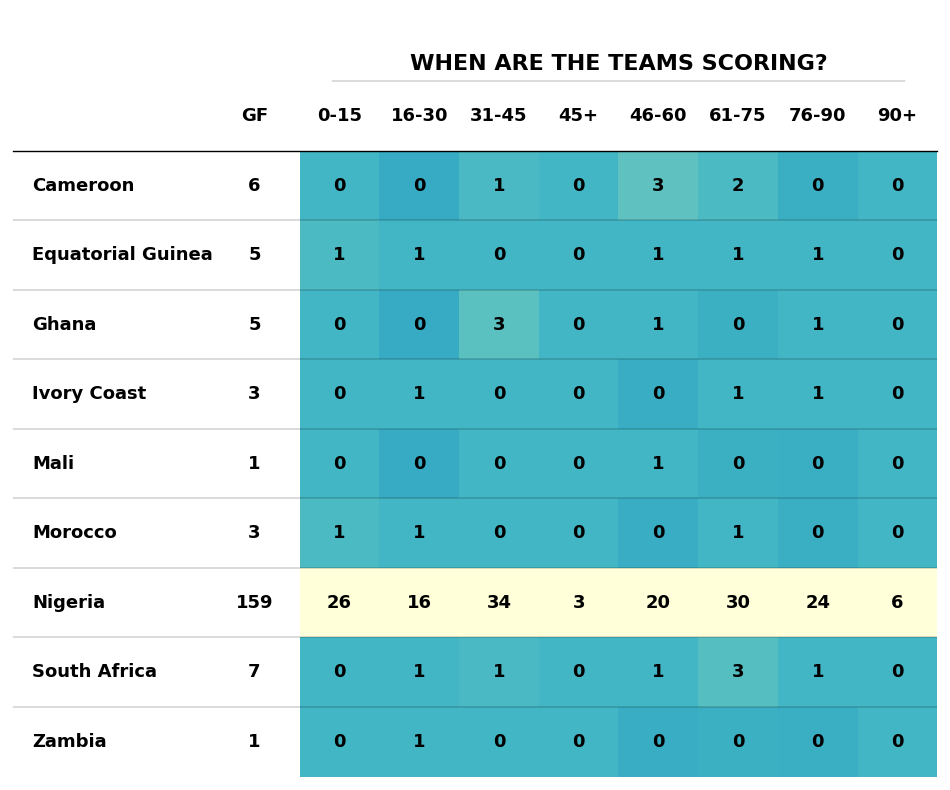

group,Goals,0-15,16-30,31-45,45+,46-60,61-75,76-90,90+
Team,,,,,,,,,
Cameroon,6,0,0,1,0,3,2,0,0
Equatorial Guinea,5,1,1,0,0,1,1,1,0
Ghana,5,0,0,3,0,1,0,1,0
Ivory Coast,3,0,1,0,0,0,1,1,0
Mali,1,0,0,0,0,1,0,0,0
Morocco,3,1,1,0,0,0,1,0,0
Nigeria,159,26,16,34,3,20,30,24,6
South Africa,7,0,1,1,0,1,3,1,0
Zambia,1,0,1,0,0,0,0,0,0


In [ ]:
pl_time_dist_of_goals(df=nga_fixed_gls, dist="goals_for",
                         list_of_teams=None, logos_fpath=None)

In [ ]:
# pl_time_dist_of_goals(df=nga_fixed_gls, dist="goals_against",
#                          list_of_teams=None, logos_fpath=None)

/tmp/ipykernel_762/1594553698.py:82: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  grouped_df = df_cleaned.pivot_table(


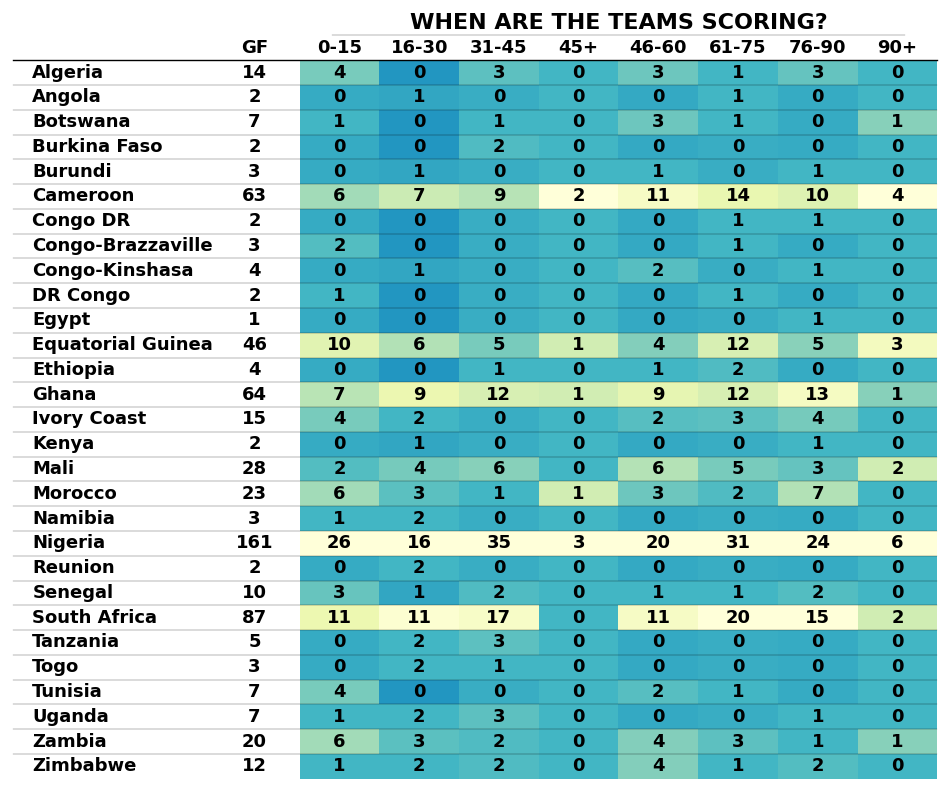

group,Goals,0-15,16-30,31-45,45+,46-60,61-75,76-90,90+
Team,,,,,,,,,
Algeria,14,4,0,3,0,3,1,3,0
Angola,2,0,1,0,0,0,1,0,0
Botswana,7,1,0,1,0,3,1,0,1
Burkina Faso,2,0,0,2,0,0,0,0,0
Burundi,3,0,1,0,0,1,0,1,0
Cameroon,63,6,7,9,2,11,14,10,4
Congo DR,2,0,0,0,0,0,1,1,0
Congo-Brazzaville,3,2,0,0,0,0,1,0,0
Congo-Kinshasa,4,0,1,0,0,2,0,1,0


In [ ]:
pl_time_dist_of_goals(df=all_goals, dist="goals_for",
                         list_of_teams=None, logos_fpath=None)

/tmp/ipykernel_762/1594553698.py:82: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  grouped_df = df_cleaned.pivot_table(


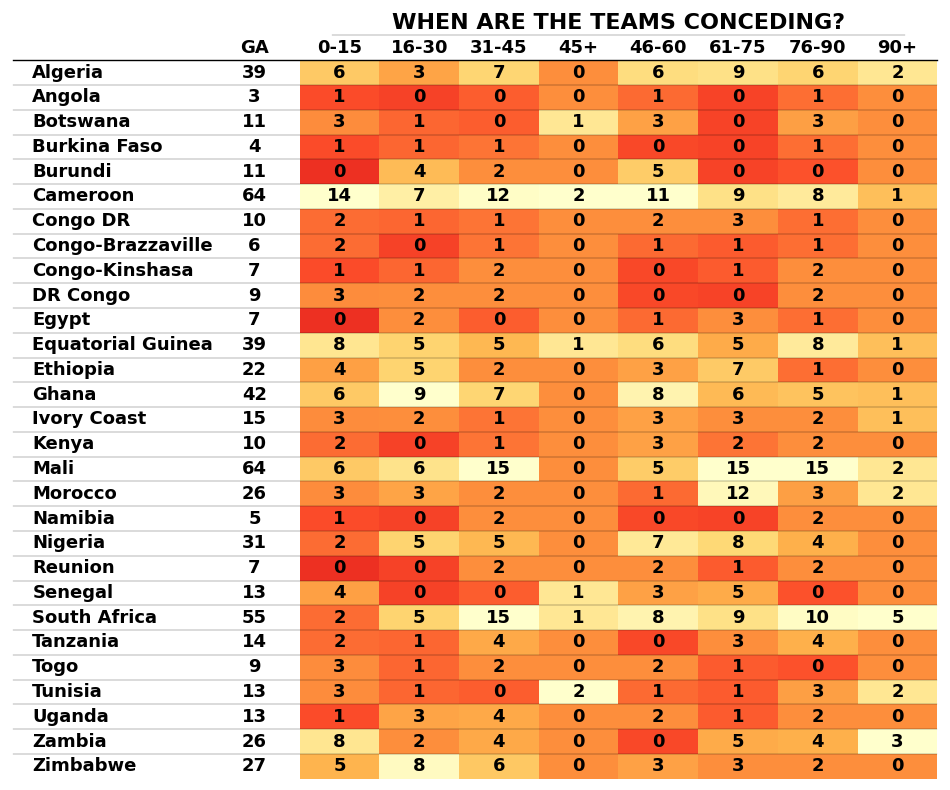

group,Goals,0-15,16-30,31-45,45+,46-60,61-75,76-90,90+
Opponent,,,,,,,,,
Algeria,39,6,3,7,0,6,9,6,2
Angola,3,1,0,0,0,1,0,1,0
Botswana,11,3,1,0,1,3,0,3,0
Burkina Faso,4,1,1,1,0,0,0,1,0
Burundi,11,0,4,2,0,5,0,0,0
Cameroon,64,14,7,12,2,11,9,8,1
Congo DR,10,2,1,1,0,2,3,1,0
Congo-Brazzaville,6,2,0,1,0,1,1,1,0
Congo-Kinshasa,7,1,1,2,0,0,1,2,0


In [ ]:
pl_time_dist_of_goals(df=all_goals, dist="goals_against",
                         list_of_teams=None, logos_fpath=None)

# Stoppage Time Goals

In [ ]:
# Stoppage Time Goals
import pandas as pd
import numpy as np
import re

# Assuming your dataframe is called 'goals_df' with columns:
# Season, Player Name, Team Name, Date, Team Faced, Goals Scored, Goal Time

def extract_minute(goal_time):
    """
    Extract numeric minute from goal time strings like '45', '45+2', '90+3', etc.
    Returns both the base minute and the stoppage time value
    """
    if pd.isna(goal_time) or goal_time == '':
        return None, None

    # Convert to string and remove any whitespace
    goal_time = str(goal_time).strip()

    # Check for stoppage time pattern (e.g., 45+2, 90+3)
    stoppage_pattern = r'(\d+)\+(\d+)'
    stoppage_match = re.search(stoppage_pattern, goal_time)

    if stoppage_match:
        base_minute = int(stoppage_match.group(1))
        stoppage_minutes = int(stoppage_match.group(2))
        total_minute = base_minute + stoppage_minutes
        return total_minute, stoppage_minutes

    # Regular minute (just a number)
    simple_pattern = r'(\d+)'
    simple_match = re.search(simple_pattern, goal_time)
    if simple_match:
        return int(simple_match.group(1)), 0

    return None, None

def classify_goal_period(minute):
    """
    Classify which half a goal belongs to based on minute
    First half: 1-45 (including stoppage time up to 45+)
    Second half: 46-90 (including stoppage time up to 90+)
    Extra time: 91-120
    """
    if minute is None:
        return 'Unknown'
    if minute <= 45:
        return 'First Half'
    elif minute <= 90:
        return 'Second Half'
    else:
        return 'Extra Time'



# Add minute information to the dataframe
def process_goal_times(goals_df):
    """
    Process the Goal Time column to extract minute information
    """
    df = goals_df.copy()

    # Extract minute information
    df[['Minute', 'Stoppage_Time']] = df['Goal_Time'].apply(
        lambda x: pd.Series(extract_minute(x))
    )

    # Classify which half the goal was scored in
    df['Period'] = df['Minute'].apply(classify_goal_period)

    # Create a flag for stoppage time goals
    df['Is_Stoppage_Time'] = df['Stoppage_Time'] > 0

    # Create a descriptive column for display
    df['Minute_Display'] = df.apply(
        lambda row: f"{row['Minute']}'" if row['Stoppage_Time'] == 0
        else f"{row['Minute'] - row['Stoppage_Time']}+{row['Stoppage_Time']}' ({row['Minute']}')",
        axis=1
    )

    return df


# Create a function to find the latest goal in any specific tournament or season
def find_latest_goals(goals_df, season=None, team=None, period='all'):
    """
    Find the latest goals with optional filters
    """
    df = process_goal_times(goals_df)

    # Apply filters
    if season:
        df = df[df['Season'] == season]
    if team:
        df = df[df['Team'] == team]

    if period.lower() == 'first half':
        df = df[df['Period'] == 'First Half']
    elif period.lower() == 'second half':
        df = df[df['Period'] == 'Second Half']
    elif period.lower() == 'extra time':
        df = df[df['Period'] == 'Extra Time']

    if df.empty:
        return "No goals found matching the criteria"

    latest = df.loc[df['Minute'].idxmax()]

    result = {
        'Season': latest['Season'],
        'Player': latest['Player'],
        'Team': latest['Team'],
        'Opponent': latest['Opponent'],
        'Minute': latest['Minute_Display'],
        'Period': latest['Period'],
        'Stoppage Time': latest['Is_Stoppage_Time']
    }

    return result


In [ ]:

# Apply the processing
print("=" * 70)
print("GOAL TIME ANALYSIS - LATEST GOALS")
print("=" * 70)

# Process the goal times
all_goals_0024 = all_goals.loc[all_goals['Season'] >= 2000]
processed_goals = process_goal_times(all_goals_0024)

print("\nSample of processed data:")
display(processed_goals[['Season', 'Player', 'Team', 'Minute_Display', 'Period', 'Is_Stoppage_Time']].head(10))


GOAL TIME ANALYSIS - LATEST GOALS

Sample of processed data:


,Season,Player,Team,Minute_Display,Period,Is_Stoppage_Time
2,2000,Phewa,South Africa,33.0',First Half,False
3,2000,Ellis,South Africa,55.0',Second Half,False
4,2000,Malaku,South Africa,69.0',Second Half,False
5,2000,Mathobela,Zimbabwe,26.0',First Half,False
6,2000,Moyo,Zimbabwe,79.0',Second Half,False
7,2000,Nakawagi,Uganda,21.0',First Half,False
8,2000,Nakintu,Uganda,30.0',First Half,False
9,2000,Mercy Akide,Nigeria,40.0',First Half,False
10,2000,Mercy Akide,Nigeria,50.0',Second Half,False
11,2000,Baidu,Ghana,52.0',Second Half,False


In [ ]:

# Find the latest goals in first half
print("\n" + "-" * 50)
print("LATEST FIRST HALF GOALS")
print("-" * 50)

first_half_goals = processed_goals[processed_goals['Period'] == 'First Half']
if not first_half_goals.empty:
    # Find the maximum minute in first half
    latest_first_half_minute = first_half_goals['Minute'].max()
    latest_first_half_goals = first_half_goals[first_half_goals['Minute'] == latest_first_half_minute]

    print(f"Latest first half goal minute: {latest_first_half_minute}'")
    print("\nGoals scored at this time:")
    for _, goal in latest_first_half_goals.iterrows():
        print(f"  {goal['Season']} - {goal['Player']} ({goal['Team']}) vs {goal['Opponent']}: {goal['Minute_Display']}")
else:
    print("No first half goals found in data")

# Find the latest goals in full time (second half + extra time)
print("\n" + "-" * 50)
print("LATEST FULL TIME GOALS (Second Half + Extra Time)")
print("-" * 50)

full_time_goals = processed_goals[processed_goals['Period'].isin(['Second Half', 'Extra Time'])]
if not full_time_goals.empty:
    # Find the maximum minute in full time
    latest_full_time_minute = full_time_goals['Minute'].max()
    latest_full_time_goals = full_time_goals[full_time_goals['Minute'] == latest_full_time_minute]

    print(f"Latest full time goal minute: {latest_full_time_minute}'")
    print("\nGoals scored at this time:")
    for _, goal in latest_full_time_goals.iterrows():
        period_note = " (STOPPAGE TIME)" if goal['Is_Stoppage_Time'] else ""
        print(f"  {goal['Season']} - {goal['Player']} ({goal['Team']}) vs {goal['Opponent']}: {goal['Minute_Display']}{period_note}")
else:
    print("No full time goals found in data")

# Also find the latest goals in each season
print("\n" + "-" * 50)
print("LATEST GOALS BY SEASON")
print("-" * 50)

for season in sorted(processed_goals['Season'].unique()):
    season_goals = processed_goals[processed_goals['Season'] == season]

    if not season_goals.empty:
        # Latest in first half for this season
        season_fh = season_goals[season_goals['Period'] == 'First Half']
        if not season_fh.empty:
            latest_fh = season_fh.loc[season_fh['Minute'].idxmax()]
            print(f"\n{season} - Latest First Half:")
            print(f"  {latest_fh['Player']} ({latest_fh['Team']}) vs {latest_fh['Opponent']}: {latest_fh['Minute_Display']}")

        # Latest in full time for this season
        season_ft = season_goals[season_goals['Period'].isin(['Second Half', 'Extra Time'])]
        if not season_ft.empty:
            latest_ft = season_ft.loc[season_ft['Minute'].idxmax()]
            stoppage_note = " (ST)" if latest_ft['Is_Stoppage_Time'] else ""
            print(f"{season} - Latest Full Time:")
            print(f"  {latest_ft['Player']} ({latest_ft['Team']}) vs {latest_ft['Opponent']}: {latest_ft['Minute_Display']}{stoppage_note}")



--------------------------------------------------
LATEST FIRST HALF GOALS
--------------------------------------------------
Latest first half goal minute: 45.0'

Goals scored at this time:
  2004 - Nabila Imloul (Algeria) vs Mali: 45.0'
  2004 - Birtukan Gebrekirstos (Ethiopia) vs South Africa: 45.0'
  2006 - Nkwocha (Nigeria) vs Cameroon: 45.0'
  2008 - Ngono Mani (Cameroon) vs Congo-Brazzaville: 45.0'
  2014 - Cudjoe (Ghana) vs South Africa: 45.0'
  2014 - Asisat Oshoala (Nigeria) vs South Africa: 45.0'
  2024 - Saratou Traore (Mali) vs Tanzania: 45.0'
  2024 - Chinwedu Ihezuo (Nigeria) vs Zambia: 45.0'
  2024 - Rasheedat Ajibade (Nigeria) vs South Africa: 45.0'
  2024 - Nonhlanhla Mthandi (South Africa) vs Ghana: 45.0'

--------------------------------------------------
LATEST FULL TIME GOALS (Second Half + Extra Time)
--------------------------------------------------
Latest full time goal minute: 128.0'

Goals scored at this time:
  2010 - Dlamini (South Africa) vs Equatorial G

In [ ]:

# Stoppage time goals analysis
print("\n" + "-" * 50)
print("STOPPAGE TIME GOALS")
print("-" * 50)

stoppage_goals = processed_goals[processed_goals['Is_Stoppage_Time']]
if not stoppage_goals.empty:
    print(f"Total stoppage time goals: {len(stoppage_goals)}")

    # Stoppage time goals by period
    stoppage_by_period = stoppage_goals.groupby('Period').size()
    print("\nStoppage time goals by period:")
    for period, count in stoppage_by_period.items():
        print(f"  {period}: {count} goals")

    # Latest stoppage time goals
    latest_stoppage = stoppage_goals.loc[stoppage_goals['Minute'].idxmax()]
    print(f"\nLatest stoppage time goal:")
    print(f"  {latest_stoppage['Season']} - {latest_stoppage['Player']} ({latest_stoppage['Team']}) vs {latest_stoppage['Opponent']}: {latest_stoppage['Minute_Display']}")
else:
    print("No stoppage time goals found in data")



--------------------------------------------------
STOPPAGE TIME GOALS
--------------------------------------------------
Total stoppage time goals: 22

Stoppage time goals by period:
  Extra Time: 14 goals
  Second Half: 8 goals

Latest stoppage time goal:
  2010 - Dlamini (South Africa) vs Equatorial Guinea: 120.0+8.0' (128.0')


In [ ]:

# Create a summary dataframe of latest goals
print("\n" + "-" * 50)
print("SUMMARY - LATEST GOALS EVER")
print("-" * 50)

# Overall latest first half goal
if not first_half_goals.empty:
    overall_latest_fh = first_half_goals.loc[first_half_goals['Minute'].idxmax()]
    print(f"Latest First Half Goal Ever:")
    print(f"  {overall_latest_fh['Season']} - {overall_latest_fh['Player']} ({overall_latest_fh['Team']}) vs {overall_latest_fh['Opponent']}: {overall_latest_fh['Minute_Display']}")

# Overall latest full time goal
if not full_time_goals.empty:
    overall_latest_ft = full_time_goals.loc[full_time_goals['Minute'].idxmax()]
    stoppage_note = " (Stoppage Time)" if overall_latest_ft['Is_Stoppage_Time'] else ""
    print(f"\nLatest Full Time Goal Ever:")
    print(f"  {overall_latest_ft['Season']} - {overall_latest_ft['Player']} ({overall_latest_ft['Team']}) vs {overall_latest_ft['Opponent']}: {overall_latest_ft['Minute_Display']}{stoppage_note}")



--------------------------------------------------
SUMMARY - LATEST GOALS EVER
--------------------------------------------------
Latest First Half Goal Ever:
  2004 - Nabila Imloul (Algeria) vs Mali: 45.0'

Latest Full Time Goal Ever:
  2010 - Dlamini (South Africa) vs Equatorial Guinea: 120.0+8.0' (128.0') (Stoppage Time)



--------------------------------------------------
GOAL TIME DISTRIBUTION
--------------------------------------------------


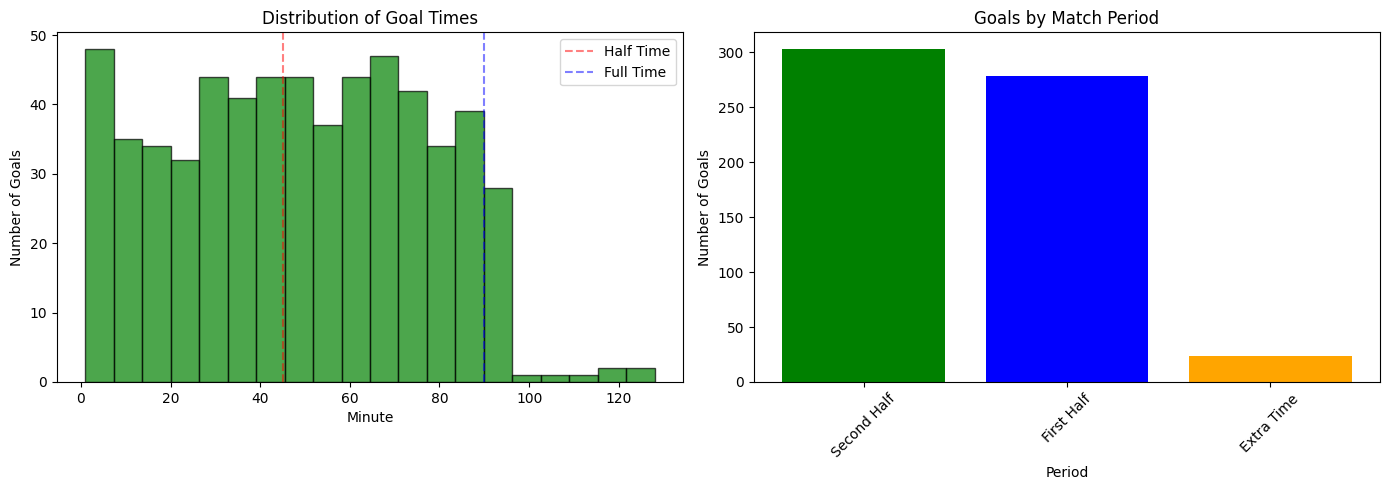

In [ ]:

# If you want to visualize the distribution of goal times
try:
    import matplotlib.pyplot as plt

    print("\n" + "-" * 50)
    print("GOAL TIME DISTRIBUTION")
    print("-" * 50)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution of goal minutes
    axes[0].hist(processed_goals['Minute'].dropna(), bins=20, color='green', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Minute')
    axes[0].set_ylabel('Number of Goals')
    axes[0].set_title('Distribution of Goal Times')
    axes[0].axvline(x=45, color='red', linestyle='--', alpha=0.5, label='Half Time')
    axes[0].axvline(x=90, color='blue', linestyle='--', alpha=0.5, label='Full Time')
    axes[0].legend()

    # Goals by period
    period_counts = processed_goals['Period'].value_counts()
    axes[1].bar(period_counts.index, period_counts.values, color=['green', 'blue', 'orange'])
    axes[1].set_xlabel('Period')
    axes[1].set_ylabel('Number of Goals')
    axes[1].set_title('Goals by Match Period')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

except ImportError:
    print("Matplotlib not available for visualization")

# **Group Stage Points**

In [ ]:
# Filter nigeria_df for 'Group Stage' matches
nigeria_group_stage_df = nigeria_df[nigeria_df['Round'] == 'Group Stage'].copy()

# Initialize points for Nigeria
nigeria_points = 0

# Iterate through each group stage match
for index, row in nigeria_group_stage_df.iterrows():
    if row['Home Team'] == 'Nigeria':
        # Nigeria is home team
        if row['FTHG'] > row['FTAG']:
            nigeria_points += 3 # Win
        elif row['FTHG'] == row['FTAG']:
            nigeria_points += 1 # Draw
        # No points added for loss
    elif row['Away Team'] == 'Nigeria':
        # Nigeria is away team
        if row['FTAG'] > row['FTHG']:
            nigeria_points += 3 # Win
        elif row['FTAG'] == row['FTHG']:
            nigeria_points += 1 # Draw
        # No points added for loss

print(f"Nigeria's total points in the Group Stages: {nigeria_points}")

Nigeria's total points in the Group Stages: 96


In [ ]:
# Initialize counters
wins = 0
draws = 0
losses = 0

# Iterate through each group stage match
for index, row in nigeria_group_stage_df.iterrows():
    if row['Home Team'] == 'Nigeria':
        # Nigeria is home team
        if row['FTHG'] > row['FTAG']:
            wins += 1
        elif row['FTHG'] == row['FTAG']:
            draws += 1
        else:
            losses += 1
    elif row['Away Team'] == 'Nigeria':
        # Nigeria is away team
        if row['FTAG'] > row['FTHG']:
            wins += 1
        elif row['FTAG'] == row['FTHG']:
            draws += 1
        else:
            losses += 1

print("\nNigeria's Group Stage Breakdown:")
print(f"Wins: {wins}")
print(f"Draws: {draws}")
print(f"Losses: {losses}")
print(f"Total matches: {wins + draws + losses}")


Nigeria's Group Stage Breakdown:
Wins: 30
Draws: 6
Losses: 3
Total matches: 39


# Task
Summarize the top five teams with the most points in the group stages from the `group_stage_df` dataframe.

In [ ]:
team_points = {}

# Iterate through each row of the group_stage_df DataFrame
for index, row in group_stage_df.iterrows():
    home_team = row['Home Team']
    away_team = row['Away Team']
    home_goals = row['FTHG']
    away_goals = row['FTAG']

    # Ensure teams are initialized in the dictionary
    if home_team not in team_points:
        team_points[home_team] = 0
    if away_team not in team_points:
        team_points[away_team] = 0

    # Update points based on match outcome
    if home_goals > away_goals:
        team_points[home_team] += 3  # Home team wins
    elif home_goals < away_goals:
        team_points[away_team] += 3  # Away team wins
    else:
        team_points[home_team] += 1  # Draw
        team_points[away_team] += 1  # Draw

print("\nGroup Stage Points for Each Team:")
# Sort teams by points in descending order and print
sorted_team_points = sorted(team_points.items(), key=lambda x: x[1], reverse=True)

# Print only the top 10 teams for brevity
N = 100
print(f"\nTop {N} Teams by Group Stage Points:")
for team, points in sorted_team_points[:N]:
    print(f"{team}: {points} points")


Group Stage Points for Each Team:

Top 100 Teams by Group Stage Points:
Nigeria: 96 points
South Africa: 71 points
Ghana: 66 points
Cameroon: 63 points
Equatorial Guinea: 26 points
Mali: 21 points
Morocco: 20 points
Zambia: 19 points
Algeria: 12 points
Zimbabwe: 11 points
Senegal: 9 points
Ivory Coast: 7 points
Ethiopia: 6 points
Botswana: 6 points
Uganda: 5 points
Tunisia: 5 points
Congo Kinshasa: 4 points
Egypt: 3 points
Congo-Brazzaville: 3 points
Congo DR: 3 points
Namibia: 3 points
Angola: 2 points
Congo-Kinshasa: 1 points
Tanzania: 1 points
Burkina Faso: 1 points
Togo: 1 points
Reunion: 0 points
Kenya: 0 points
Burundi: 0 points
DR Congo: 0 points


# Clean Sheets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# Assuming your dataframe is called 'df'
# Let's create a function to calculate clean sheets for any team

def calculate_clean_sheets(df, team_name=None):
    """
    Calculate clean sheets for a specific team or all teams

    Parameters:
    df: DataFrame with match data
    team_name: Optional team name to filter for (e.g., 'Nigeria')

    Returns:
    DataFrame with clean sheet records
    """
    if team_name:
        # Filter for matches involving the specific team
        team_matches = df[(df['Home Team'] == team_name) | (df['Away Team'] == team_name)].copy()
    else:
        # For all teams, we'll create a comprehensive dataframe
        team_matches = df.copy()

    # Initialize list to store clean sheet records
    clean_sheets = []

    for idx, row in team_matches.iterrows():
        # Check if home team kept a clean sheet
        if pd.notna(row['FTAG']) and row['FTAG'] == 0:
            clean_sheets.append({
                'Date': row['Date'],
                'Season': row['Season'],
                'Round': row['Round'],
                'Team': row['Home Team'],
                'Opponent': row['Away Team'],
                'Venue': 'Home',
                'Score': f"{row['FTHG']}-{row['FTAG']}",
                'FTHG': row['FTHG'],
                'FTAG': row['FTAG'],
                'Clean_Sheet_Type': 'Home Clean Sheet'
            })

        # Check if away team kept a clean sheet
        if pd.notna(row['FTHG']) and row['FTHG'] == 0:
            clean_sheets.append({
                'Date': row['Date'],
                'Season': row['Season'],
                'Round': row['Round'],
                'Team': row['Away Team'],
                'Opponent': row['Home Team'],
                'Venue': 'Away',
                'Score': f"{row['FTHG']}-{row['FTAG']}",
                'FTHG': row['FTHG'],
                'FTAG': row['FTAG'],
                'Clean_Sheet_Type': 'Away Clean Sheet'
            })

    return pd.DataFrame(clean_sheets)


In [ ]:
df = df_copy

# Calculate clean sheets for all teams
print("=" * 80)
print("CLEAN SHEETS AT THE WOMEN'S AFRICA CUP OF NATIONS")
print("=" * 80)

all_clean_sheets = calculate_clean_sheets(df)

if len(all_clean_sheets) > 0:
    print(f"\nTotal Clean Sheets Recorded: {len(all_clean_sheets)}")

    # Clean sheets by season
    print("\n" + "-" * 50)
    print("CLEAN SHEETS BY SEASON")
    print("-" * 50)

    clean_sheets_by_season = all_clean_sheets.groupby('Season').size().sort_index()
    for season, count in clean_sheets_by_season.items():
        print(f"  {season}: {count} clean sheets")

    # Clean sheets by team (Top 10)
    print("\n" + "-" * 50)
    print("TOP 10 TEAMS - MOST CLEAN SHEETS")
    print("-" * 50)

    team_clean_sheets = all_clean_sheets.groupby('Team').size().sort_values(ascending=False).head(10)
    for team, count in team_clean_sheets.items():
        home_away = all_clean_sheets[all_clean_sheets['Team'] == team]
        home_cs = len(home_away[home_away['Venue'] == 'Home'])
        away_cs = len(home_away[home_away['Venue'] == 'Away'])
        print(f"  {team}: {count} total (Home: {home_cs}, Away: {away_cs})")

    # Clean sheets by round
    print("\n" + "-" * 50)
    print("CLEAN SHEETS BY ROUND")
    print("-" * 50)

    round_clean_sheets = all_clean_sheets.groupby('Round').size().sort_values(ascending=False)
    for round_name, count in round_clean_sheets.items():
        if round_name and round_name != '':
            print(f"  {round_name}: {count} clean sheets")

    # Clean sheets by venue
    print("\n" + "-" * 50)
    print("CLEAN SHEETS BY VENUE")
    print("-" * 50)

    venue_counts = all_clean_sheets['Venue'].value_counts()
    for venue, count in venue_counts.items():
        print(f"  {venue}: {count} clean sheets")

else:
    print("No clean sheets found in the data")


CLEAN SHEETS AT THE WOMEN'S AFRICA CUP OF NATIONS

Total Clean Sheets Recorded: 142

--------------------------------------------------
CLEAN SHEETS BY SEASON
--------------------------------------------------
  1998: 8 clean sheets
  2000: 9 clean sheets
  2002: 10 clean sheets
  2004: 10 clean sheets
  2006: 9 clean sheets
  2008: 9 clean sheets
  2010: 5 clean sheets
  2012: 13 clean sheets
  2014: 9 clean sheets
  2016: 13 clean sheets
  2018: 11 clean sheets
  2022: 18 clean sheets
  2024: 18 clean sheets

--------------------------------------------------
TOP 10 TEAMS - MOST CLEAN SHEETS
--------------------------------------------------
  Nigeria: 43 total (Home: 28, Away: 15)
  South Africa: 22 total (Home: 13, Away: 9)
  Cameroon: 19 total (Home: 15, Away: 4)
  Ghana: 15 total (Home: 9, Away: 6)
  Equatorial Guinea: 8 total (Home: 8, Away: 0)
  Algeria: 6 total (Home: 4, Away: 2)
  Senegal: 5 total (Home: 3, Away: 2)
  Zambia: 5 total (Home: 3, Away: 2)
  Morocco: 4 total (Hom

In [ ]:
df = df_copy

# Calculate clean sheets for all teams
print("=" * 80)
print("CLEAN SHEETS AT THE WOMEN'S AFRICA CUP OF NATIONS")
print("=" * 80)

all_clean_sheets = calculate_clean_sheets(df)

if len(all_clean_sheets) > 0:
    print(f"\nTotal Clean Sheets Recorded: {len(all_clean_sheets)}")

    # Clean sheets by season
    print("\n" + "-" * 50)
    print("CLEAN SHEETS BY SEASON")
    print("-" * 50)

    clean_sheets_by_season = all_clean_sheets.groupby('Season').size().sort_index()
    for season, count in clean_sheets_by_season.items():
        print(f"  {season}: {count} clean sheets")

    # Clean sheets by team (Top 10)
    print("\n" + "-" * 50)
    print("TOP 10 TEAMS - MOST CLEAN SHEETS")
    print("-" * 50)

    team_clean_sheets = all_clean_sheets.groupby('Team').size().sort_values(ascending=False).head(10)
    for team, count in team_clean_sheets.items():
        home_away = all_clean_sheets[all_clean_sheets['Team'] == team]
        home_cs = len(home_away[home_away['Venue'] == 'Home'])
        away_cs = len(home_away[home_away['Venue'] == 'Away'])
        print(f"  {team}: {count} total (Home: {home_cs}, Away: {away_cs})")

    # Clean sheets by round
    print("\n" + "-" * 50)
    print("CLEAN SHEETS BY ROUND")
    print("-" * 50)

    round_clean_sheets = all_clean_sheets.groupby('Round').size().sort_values(ascending=False)
    for round_name, count in round_clean_sheets.items():
        if round_name and round_name != '':
            print(f"  {round_name}: {count} clean sheets")

    # Clean sheets by venue
    print("\n" + "-" * 50)
    print("CLEAN SHEETS BY VENUE")
    print("-" * 50)

    venue_counts = all_clean_sheets['Venue'].value_counts()
    for venue, count in venue_counts.items():
        print(f"  {venue}: {count} clean sheets")

else:
    print("No clean sheets found in the data")




CLEAN SHEETS AT THE WOMEN'S AFRICA CUP OF NATIONS

Total Clean Sheets Recorded: 142

--------------------------------------------------
CLEAN SHEETS BY SEASON
--------------------------------------------------
  1998: 8 clean sheets
  2000: 9 clean sheets
  2002: 10 clean sheets
  2004: 10 clean sheets
  2006: 9 clean sheets
  2008: 9 clean sheets
  2010: 5 clean sheets
  2012: 13 clean sheets
  2014: 9 clean sheets
  2016: 13 clean sheets
  2018: 11 clean sheets
  2022: 18 clean sheets
  2024: 18 clean sheets

--------------------------------------------------
TOP 10 TEAMS - MOST CLEAN SHEETS
--------------------------------------------------
  Nigeria: 43 total (Home: 28, Away: 15)
  South Africa: 22 total (Home: 13, Away: 9)
  Cameroon: 19 total (Home: 15, Away: 4)
  Ghana: 15 total (Home: 9, Away: 6)
  Equatorial Guinea: 8 total (Home: 8, Away: 0)
  Algeria: 6 total (Home: 4, Away: 2)
  Senegal: 5 total (Home: 3, Away: 2)
  Zambia: 5 total (Home: 3, Away: 2)
  Morocco: 4 total (Hom

In [ ]:
# df = nigeria_df
df = df_copy

# Calculate clean sheets specifically for Nigeria
print("\n" + "=" * 80)
print("NIGERIA'S CLEAN SHEETS AT THE WOMEN'S AFRICA CUP OF NATIONS")
print("=" * 80)

nigeria_clean_sheets = calculate_clean_sheets(df, team_name='Nigeria')

if len(nigeria_clean_sheets) > 0:
    print(f"\nTotal Clean Sheets by Nigeria: {len(nigeria_clean_sheets)}")

    # Nigeria clean sheets by season
    print("\n" + "-" * 50)
    print("NIGERIA CLEAN SHEETS BY SEASON")
    print("-" * 50)

    nigeria_by_season = nigeria_clean_sheets.groupby('Season').size().sort_index()
    for season, count in nigeria_by_season.items():
        print(f"  {season}: {count} clean sheets")

    # List all Nigeria clean sheet matches
    print("\n" + "-" * 50)
    print("NIGERIA CLEAN SHEET MATCHES (DETAILED)")
    print("-" * 50)

    # Sort by date
    nigeria_clean_sheets_sorted = nigeria_clean_sheets.sort_values('Date')

    for idx, row in nigeria_clean_sheets_sorted.iterrows():
        print(f"\n  📅 {row['Date']} | Season: {row['Season']}")
        print(f"     🏆 Round: {row['Round']}")
        print(f"     ⚽ {row['Team']} vs {row['Opponent']} ({row['Venue']})")
        print(f"     📊 Score: {row['Score']}")

        # Add special marker for big clean sheets
        if row['FTAG'] == 0 and row['FTHG'] >= 3:
            print(f"     💪 IMPRESSIVE CLEAN SHEET WITH {row['FTHG']} GOALS SCORED!")

    # Nigeria clean sheets by round
    print("\n" + "-" * 50)
    print("NIGERIA CLEAN SHEETS BY ROUND")
    print("-" * 50)

    nigeria_by_round = nigeria_clean_sheets.groupby('Round').size().sort_values(ascending=False)
    for round_name, count in nigeria_by_round.items():
        if round_name and round_name != '':
            print(f"  {round_name}: {count} clean sheets")

    # Nigeria clean sheets by opponent
    print("\n" + "-" * 50)
    print("NIGERIA CLEAN SHEETS BY OPPONENT")
    print("-" * 50)

    nigeria_by_opponent = nigeria_clean_sheets.groupby('Opponent').size().sort_values(ascending=False)
    for opponent, count in nigeria_by_opponent.items():
        print(f"  vs {opponent}: {count} clean sheets")

else:
    print("No clean sheets found for Nigeria")

# Create a visualization of clean sheets
print("\n" + "=" * 80)
print("CREATING CLEAN SHEETS VISUALIZATION")
print("=" * 80)



NIGERIA'S CLEAN SHEETS AT THE WOMEN'S AFRICA CUP OF NATIONS

Total Clean Sheets by Nigeria: 53

--------------------------------------------------
NIGERIA CLEAN SHEETS BY SEASON
--------------------------------------------------
  1998: 5 clean sheets
  2000: 4 clean sheets
  2002: 4 clean sheets
  2004: 4 clean sheets
  2006: 4 clean sheets
  2008: 4 clean sheets
  2010: 2 clean sheets
  2012: 3 clean sheets
  2014: 3 clean sheets
  2016: 4 clean sheets
  2018: 7 clean sheets
  2022: 4 clean sheets
  2024: 5 clean sheets

--------------------------------------------------
NIGERIA CLEAN SHEET MATCHES (DETAILED)
--------------------------------------------------

  📅 06-Jul-25 | Season: 2024
     🏆 Round: Group Stage
     ⚽ Nigeria vs Tunisia (Home)
     📊 Score: 3-0
     💪 IMPRESSIVE CLEAN SHEET WITH 3 GOALS SCORED!

  📅 1-Dec-18 | Season: 2018
     🏆 Round: Final
     ⚽ Nigeria vs South Africa (Home)
     📊 Score: 0-0

  📅 1-Dec-18 | Season: 2018
     🏆 Round: Final
     ⚽ South Afri

/tmp/ipykernel_762/2049464543.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


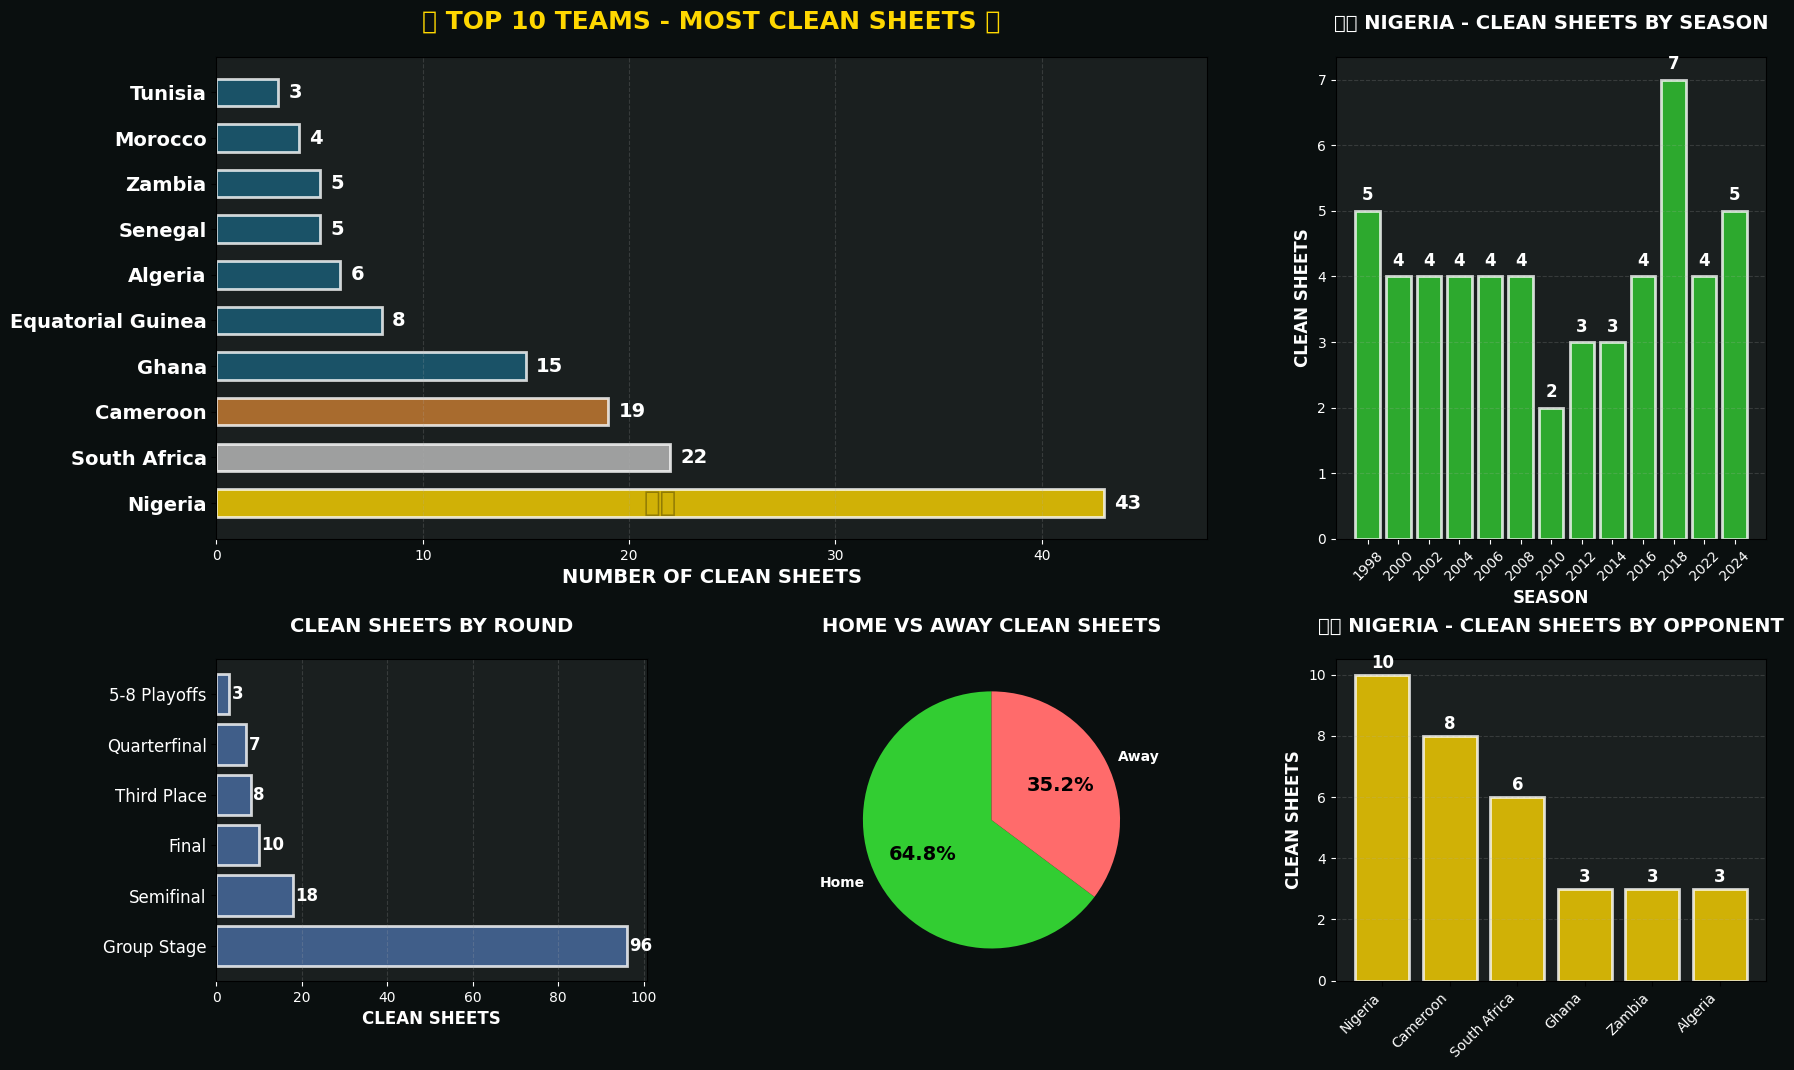


NIGERIA CLEAN SHEETS - DETAILED TABLE
 Season      Date        Round          Opponent Venue Score
   2024 06-Jul-25  Group Stage           Tunisia  Home   3-0
   2018  1-Dec-18        Final      South Africa  Home   0-0
   2018  1-Dec-18        Final           Nigeria  Away   0-0
   2010  1-Nov-10  Group Stage              Mali  Home   5-0
   2012  1-Nov-12  Group Stage          Ethiopia  Away   0-3
   2002 10-Dec-02  Group Stage           Nigeria  Away   0-1
   2022 10-Jul-22  Group Stage           Burundi  Home   4-0
   2024 10-Jul-25  Group Stage          Botswana  Away   0-1
   2006 11-Nov-06        Final             Ghana  Home   1-0
   2012 11-Nov-12  Third Place           Nigeria  Home   1-0
   2022 14-Jul-22 Quarterfinal          Cameroon  Away   0-1
   2014 14-Oct-14  Group Stage            Zambia  Away   0-6
   2024 15-Jul-25  Group Stage           Algeria  Home   0-0
   2024 15-Jul-25  Group Stage           Nigeria  Away   0-0
   2000 15-Nov-00  Group Stage           Moroc

In [ ]:

# Set up the figure with a dark theme
fig = plt.figure(figsize=(20, 12), facecolor='#0a0f0f')
fig.patch.set_facecolor('#0a0f0f')

# Create grid for subplots
gs = gridspec.GridSpec(2, 3, height_ratios=[1.5, 1], hspace=0.3, wspace=0.3)

# 1. Main bar chart - Top teams clean sheets (top left spanning 2 columns)
ax1 = plt.subplot(gs[0, :2], facecolor='#1a1f1f')

# Get top 10 teams for clean sheets
top_teams_cs = team_clean_sheets.head(10)
teams = top_teams_cs.index.tolist()
cs_counts = top_teams_cs.values.tolist()

# Create gradient colors
colors = ['#ffd700', '#c0c0c0', '#cd7f32'] + ['#1a5f7a'] * 7  # Gold, silver, bronze for top 3

# Create horizontal bars
y_pos = np.arange(len(teams))
bars = ax1.barh(y_pos, cs_counts, color=colors, alpha=0.8, edgecolor='white', linewidth=2, height=0.6)

# Add value labels and team names
for i, (bar, team, count) in enumerate(zip(bars, teams, cs_counts)):
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{count}',
            ha='left', va='center', fontsize=14, fontweight='bold', color='white')

    # Add Nigeria special marker
    if team == 'Nigeria':
        ax1.text(width/2, bar.get_y() + bar.get_height()/2, '🇳🇬',
                ha='center', va='center', fontsize=20, alpha=0.3)

# Customize
ax1.set_yticks(y_pos)
ax1.set_yticklabels(teams, fontsize=14, fontweight='bold', color='white')
ax1.set_xlabel('NUMBER OF CLEAN SHEETS', fontsize=14, fontweight='bold', color='white')
ax1.set_title('🏆 TOP 10 TEAMS - MOST CLEAN SHEETS 🏆', fontsize=18, fontweight='bold', color='#ffd700', pad=20)
ax1.grid(axis='x', alpha=0.2, linestyle='--')
ax1.tick_params(axis='x', colors='white')
ax1.set_xlim(0, max(cs_counts) + 5)

# 2. Nigeria clean sheets by season (top right)
ax2 = plt.subplot(gs[0, 2], facecolor='#1a1f1f')

if len(nigeria_clean_sheets) > 0:
    nigeria_season_counts = nigeria_clean_sheets.groupby('Season').size()
    seasons = [str(s) for s in nigeria_season_counts.index.tolist()]
    season_cs = nigeria_season_counts.values.tolist()

    # Create vertical bars
    bars2 = ax2.bar(seasons, season_cs, color='#32CD32', alpha=0.8, edgecolor='white', linewidth=2)

    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{int(height)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='white')

    ax2.set_xlabel('SEASON', fontsize=12, fontweight='bold', color='white')
    ax2.set_ylabel('CLEAN SHEETS', fontsize=12, fontweight='bold', color='white')
    ax2.set_title('🇳🇬 NIGERIA - CLEAN SHEETS BY SEASON', fontsize=14, fontweight='bold', color='white', pad=20)
    ax2.tick_params(axis='x', rotation=45, colors='white')
    ax2.tick_params(axis='y', colors='white')
    ax2.grid(axis='y', alpha=0.2, linestyle='--')
else:
    ax2.text(0.5, 0.5, 'No Nigeria clean sheets found', ha='center', va='center',
            fontsize=14, color='white', transform=ax2.transAxes)

# 3. Clean sheets by round (bottom left)
ax3 = plt.subplot(gs[1, 0], facecolor='#1a1f1f')

if len(all_clean_sheets) > 0:
    round_cs = all_clean_sheets.groupby('Round').size().sort_values(ascending=False).head(8)
    rounds = [r if r else 'Unknown' for r in round_cs.index.tolist()]
    round_counts = round_cs.values.tolist()

    # Create horizontal bars
    y_pos_round = np.arange(len(rounds))
    bars3 = ax3.barh(y_pos_round, round_counts, color='#4a6fa5', alpha=0.8, edgecolor='white', linewidth=2)

    # Add value labels
    for bar, count in zip(bars3, round_counts):
        width = bar.get_width()
        ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{count}',
                ha='left', va='center', fontsize=12, fontweight='bold', color='white')

    ax3.set_yticks(y_pos_round)
    ax3.set_yticklabels(rounds, fontsize=12, color='white')
    ax3.set_xlabel('CLEAN SHEETS', fontsize=12, fontweight='bold', color='white')
    ax3.set_title('CLEAN SHEETS BY ROUND', fontsize=14, fontweight='bold', color='white', pad=20)
    ax3.tick_params(axis='x', colors='white')
    ax3.grid(axis='x', alpha=0.2, linestyle='--')
else:
    ax3.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14, color='white')

# 4. Clean sheets by venue (bottom middle)
ax4 = plt.subplot(gs[1, 1], facecolor='#1a1f1f')

if len(all_clean_sheets) > 0:
    venue_counts = all_clean_sheets['Venue'].value_counts()
    venues = venue_counts.index.tolist()
    venue_vals = venue_counts.values.tolist()
    venue_colors = ['#32CD32' if v == 'Home' else '#FF6B6B' for v in venues]

    # Create pie chart
    wedges, texts, autotexts = ax4.pie(venue_vals, labels=venues, colors=venue_colors,
                                        autopct='%1.1f%%', startangle=90,
                                        textprops={'color': 'white', 'fontweight': 'bold'})
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(14)

    ax4.set_title('HOME VS AWAY CLEAN SHEETS', fontsize=14, fontweight='bold', color='white', pad=20)
else:
    ax4.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14, color='white')

# 5. Nigeria clean sheets by opponent (bottom right)
ax5 = plt.subplot(gs[1, 2], facecolor='#1a1f1f')

if len(nigeria_clean_sheets) > 0:
    nigeria_opponent = nigeria_clean_sheets.groupby('Opponent').size().sort_values(ascending=False).head(6)
    opponents = nigeria_opponent.index.tolist()
    opp_counts = nigeria_opponent.values.tolist()

    # Create vertical bars
    x_pos = np.arange(len(opponents))
    bars5 = ax5.bar(x_pos, opp_counts, color='#FFD700', alpha=0.8, edgecolor='white', linewidth=2)

    # Add value labels
    for bar, count in zip(bars5, opp_counts):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{int(height)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='white')

    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(opponents, rotation=45, ha='right', fontsize=10, color='white')
    ax5.set_ylabel('CLEAN SHEETS', fontsize=12, fontweight='bold', color='white')
    ax5.set_title('🇳🇬 NIGERIA - CLEAN SHEETS BY OPPONENT', fontsize=14, fontweight='bold', color='white', pad=20)
    ax5.tick_params(axis='y', colors='white')
    ax5.grid(axis='y', alpha=0.2, linestyle='--')
else:
    ax5.text(0.5, 0.5, 'No Nigeria clean sheets found', ha='center', va='center', fontsize=14, color='white')

plt.tight_layout()
plt.show()

# Create a detailed table of Nigeria's clean sheets
print("\n" + "=" * 80)
print("NIGERIA CLEAN SHEETS - DETAILED TABLE")
print("=" * 80)

if len(nigeria_clean_sheets) > 0:
    # Create a formatted table
    table_data = []
    for idx, row in nigeria_clean_sheets_sorted.iterrows():
        table_data.append({
            'Season': row['Season'],
            'Date': row['Date'],
            'Round': row['Round'],
            'Opponent': row['Opponent'],
            'Venue': row['Venue'],
            'Score': row['Score']
        })

    table_df = pd.DataFrame(table_data)
    print(table_df.to_string(index=False))

    # Summary statistics
    print("\n" + "-" * 50)
    print("NIGERIA CLEAN SHEETS - SUMMARY")
    print("-" * 50)
    print(f"Total Clean Sheets: {len(nigeria_clean_sheets)}")
    print(f"Most Clean Sheets in a Season: {nigeria_by_season.max()} ({nigeria_by_season.idxmax()})")
    print(f"Most Common Opponent for Clean Sheets: {nigeria_by_opponent.index[0]} ({nigeria_by_opponent.values[0]} times)")
    print(f"Home Clean Sheets: {len(nigeria_clean_sheets[nigeria_clean_sheets['Venue'] == 'Home'])}")
    print(f"Away Clean Sheets: {len(nigeria_clean_sheets[nigeria_clean_sheets['Venue'] == 'Away'])}")

    # Find the most impressive clean sheet (highest score while keeping clean sheet)
    impressive_cs = nigeria_clean_sheets.copy()
    impressive_cs['Goals_Scored'] = impressive_cs.apply(
        lambda row: row['FTHG'] if row['Venue'] == 'Home' else row['FTAG'], axis=1
    )
    best_cs = impressive_cs.loc[impressive_cs['Goals_Scored'].idxmax()]

    print(f"\nMost Impressive Clean Sheet:")
    print(f"  {best_cs['Date']} - {best_cs['Team']} {best_cs['Score']} vs {best_cs['Opponent']}")
    print(f"  (Scored {int(best_cs['Goals_Scored'])} goals while keeping clean sheet)")

else:
    print("No clean sheets found for Nigeria")

print("\n" + "★" * 80)
print("★ CLEAN SHEETS ANALYSIS COMPLETE ★")
print("★" * 80)

# Runs
-- Use `restructure_team_df(df:pd.DataFrame, team:str)`

In [ ]:
nigeria_restructured.head(1)

,Date,Season,Competition,Round,Group,Venue,Team,Opponent,HTTG,HTOG,FTTG,FTOG,Result,Clean_Sheet,Team_Goals_Scorers,Opponent_Goals_Scorers
0,17-Oct-98,1998,Womens Africa Cup of Nation,Group Stage,A,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Morocco,5,0,8,0,8-0,True,,


In [ ]:
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Optional
from datetime import datetime


def extract_outcome_from_result(result_str: str) -> str:
    """
    Extract W/L/D from result string like '8-0', '2-2', '0-1'
    """
    try:
        if pd.isna(result_str) or not isinstance(result_str, str):
            return None

        scores = result_str.split('-')
        if len(scores) != 2:
            return None

        nigeria_score = int(scores[0].strip())
        opponent_score = int(scores[1].strip())

        if nigeria_score > opponent_score:
            return 'W'
        elif nigeria_score < opponent_score:
            return 'L'
        else:
            return 'D'
    except:
        return None



def parse_mixed_dates(date_str):
    """
    Parse dates that could be in multiple formats
    """
    if pd.isna(date_str):
        return pd.NaT

    date_str = str(date_str).strip()

    try:
        return pd.to_datetime(date_str, format='%d-%b-%y')
    except:
        try:
            return pd.to_datetime(date_str, format='%Y-%m-%d')
        except:
            try:
                return pd.to_datetime(date_str)
            except:
                print(f"Warning: Could not parse date: {date_str}")
                return pd.NaT



def prepare_wafcon_data(df: pd.DataFrame, sort_recent_to_oldest: bool = True) -> pd.DataFrame:
    """
    Prepare the WAFCON data with clear sorting direction
    """
    df_prepared = df.copy()

    # Add Outcome column from Result if it doesn't exist
    if 'Outcome' not in df_prepared.columns:
        df_prepared['Outcome'] = df_prepared['Result'].apply(extract_outcome_from_result)

    # Convert Date to datetime
    df_prepared['Date'] = df_prepared['Date'].apply(parse_mixed_dates)
    df_prepared = df_prepared.dropna(subset=['Date'])

    # Sort with clear direction
    if sort_recent_to_oldest:
        df_prepared = df_prepared.sort_values(['Season', 'Date'], ascending=[False, False]).reset_index(drop=True)
        print("📅 SORTING: Most Recent → Oldest (Reverse Chronological)")
        print("   Index 0 = Most Recent Game")
        print("   Index n = Oldest Game")
    else:
        df_prepared = df_prepared.sort_values(['Season', 'Date'], ascending=[True, True]).reset_index(drop=True)
        print("📅 SORTING: Oldest → Most Recent (Chronological)")

    return df_prepared



def unbeaten_runs_wafcon(df: pd.DataFrame) -> Dict:
    """
    Calculate unbeaten runs (sequences without 'L')
    NOTE: Data is sorted from MOST RECENT to OLDEST
    """
    df_prepared = prepare_wafcon_data(df, sort_recent_to_oldest=True)
    outcomes = df_prepared['Outcome'].tolist()

    print("\n" + "="*80)
    print("🔍 UNBEATEN RUNS ANALYSIS ORIENTATION")
    print("="*80)
    print("📊 Data is sorted from MOST RECENT → OLDEST")
    print("   For unbeaten runs, we split by 'L'")
    print("   This means:")
    print("   - The FIRST game in any streak is the MOST RECENT")
    print("   - The LAST game in any streak is the OLDEST")
    print("   - The streak is ENDED BY the game that comes AFTER the oldest game")
    print("="*80 + "\n")

    # Split the list by 'L' (losses)
    sequences = []
    current_sequence = []
    current_indices = []

    for idx, outcome in enumerate(outcomes):
        if outcome != 'L':
            current_sequence.append(outcome)
            current_indices.append(idx)
        else:
            if current_sequence:
                sequences.append({
                    'streak': ''.join(current_sequence),
                    'length': len(current_sequence),
                    'games': current_sequence.copy(),
                    'indices': current_indices.copy()
                })
                current_sequence = []
                current_indices = []

    if current_sequence:
        sequences.append({
            'streak': ''.join(current_sequence),
            'length': len(current_sequence),
            'games': current_sequence.copy(),
            'indices': current_indices.copy()
        })

    # Add detailed information
    streaks_with_details = []

    for seq in sequences:
        most_recent_idx = seq['indices'][0]      # First in sequence = Most recent
        oldest_idx = seq['indices'][-1]           # Last in sequence = Oldest

        # CORRECTED: The game that ended this streak comes AFTER the oldest game
        ended_by_idx = oldest_idx + 1 if oldest_idx + 1 < len(df_prepared) else None

        # Get chronological order (oldest to most recent)
        chronological_indices = list(reversed(seq['indices']))
        chronological_games = []
        for pos, idx in enumerate(chronological_indices, 1):
            chronological_games.append({
                'position_in_streak': pos,
                'date': df_prepared.iloc[idx]['Date'].strftime('%Y-%m-%d'),
                'opponent': df_prepared.iloc[idx]['Opponent'],
                'result': df_prepared.iloc[idx]['Result'],
                'outcome': df_prepared.iloc[idx]['Outcome'],
                'season': df_prepared.iloc[idx]['Season'],
                'round': df_prepared.iloc[idx]['Round']
            })

        streak_info = {
            'streak': seq['streak'],
            'length': seq['length'],
            'games': seq['games'],
            'indices': seq['indices'],
            'type': 'unbeaten',

            # In analysis order (most recent → oldest)
            'in_analysis_order': {
                'note': 'Games as they appear in our sorted data (Most Recent → Oldest)',
                'first_game_most_recent': {
                    'index': most_recent_idx,
                    'date': df_prepared.iloc[most_recent_idx]['Date'].strftime('%Y-%m-%d'),
                    'opponent': df_prepared.iloc[most_recent_idx]['Opponent'],
                    'result': df_prepared.iloc[most_recent_idx]['Result'],
                    'outcome': df_prepared.iloc[most_recent_idx]['Outcome'],
                    'season': df_prepared.iloc[most_recent_idx]['Season'],
                    'round': df_prepared.iloc[most_recent_idx]['Round']
                },
                'last_game_oldest': {
                    'index': oldest_idx,
                    'date': df_prepared.iloc[oldest_idx]['Date'].strftime('%Y-%m-%d'),
                    'opponent': df_prepared.iloc[oldest_idx]['Opponent'],
                    'result': df_prepared.iloc[oldest_idx]['Result'],
                    'outcome': df_prepared.iloc[oldest_idx]['Outcome'],
                    'season': df_prepared.iloc[oldest_idx]['Season'],
                    'round': df_prepared.iloc[oldest_idx]['Round']
                }
            },

            # In real time order (oldest → most recent)
            'in_real_time': {
                'note': 'Games in REAL TIME order (Oldest → Most Recent)',
                'start_game_oldest': chronological_games[0] if chronological_games else None,
                'end_game_most_recent': chronological_games[-1] if chronological_games else None,
                'all_games_chronological': chronological_games
            }
        }

        # Add ended_by information
        if ended_by_idx is not None:
            streak_info['ended_by'] = {
                'note': 'This game occurred AFTER the oldest game in the streak (in real time), ending the unbeaten run',
                'index': ended_by_idx,
                'date': df_prepared.iloc[ended_by_idx]['Date'].strftime('%Y-%m-%d'),
                'opponent': df_prepared.iloc[ended_by_idx]['Opponent'],
                'result': df_prepared.iloc[ended_by_idx]['Result'],
                'outcome': df_prepared.iloc[ended_by_idx]['Outcome'],
                'season': df_prepared.iloc[ended_by_idx]['Season'],
                'round': df_prepared.iloc[ended_by_idx]['Round']
            }
        else:
            streak_info['ended_by'] = {
                'note': 'No game found after this streak - may be ongoing or data incomplete',
                'index': None
            }

        streaks_with_details.append(streak_info)

    longest_streak = max(streaks_with_details, key=lambda x: x['length']) if streaks_with_details else None

    return {
        'longest_streak': longest_streak,
        'all_streaks': streaks_with_details,
        'total_unbeaten_streaks': len(streaks_with_details),
        'sorted_outcomes': outcomes,
        'dataframe': df_prepared,
        'sorting_note': 'Data sorted from MOST RECENT to OLDEST (Reverse Chronological)'
    }



def winning_runs_wafcon(df: pd.DataFrame) -> Dict:
    """
    Calculate winning runs (sequences of only 'W')
    NOTE: Data is sorted from MOST RECENT to OLDEST
    """
    df_prepared = prepare_wafcon_data(df, sort_recent_to_oldest=True)
    outcomes = df_prepared['Outcome'].tolist()

    print("\n" + "="*80)
    print("🔍 WINNING RUNS ANALYSIS ORIENTATION")
    print("="*80)
    print("📊 Data is sorted from MOST RECENT → OLDEST")
    print("   For winning runs, we split by 'D' or 'L' (anything not 'W')")
    print("   This means:")
    print("   - The FIRST game in any streak is the MOST RECENT WIN")
    print("   - The LAST game in any streak is the OLDEST WIN")
    print("   - The streak is ENDED BY the game that comes AFTER the oldest win")
    print("="*80 + "\n")

    # Split by anything that's not 'W'
    sequences = []
    current_sequence = []
    current_indices = []

    for idx, outcome in enumerate(outcomes):
        if outcome == 'W':
            current_sequence.append(outcome)
            current_indices.append(idx)
        else:
            if current_sequence:
                sequences.append({
                    'streak': ''.join(current_sequence),
                    'length': len(current_sequence),
                    'games': current_sequence.copy(),
                    'indices': current_indices.copy()
                })
                current_sequence = []
                current_indices = []

    if current_sequence:
        sequences.append({
            'streak': ''.join(current_sequence),
            'length': len(current_sequence),
            'games': current_sequence.copy(),
            'indices': current_indices.copy()
        })

    # Add detailed information
    streaks_with_details = []

    for seq in sequences:
        most_recent_idx = seq['indices'][0]      # Most recent win
        oldest_idx = seq['indices'][-1]           # Oldest win

        # CORRECTED: The game that ended this streak comes AFTER the oldest win
        ended_by_idx = oldest_idx + 1 if oldest_idx + 1 < len(df_prepared) else None

        # Get chronological order
        chronological_indices = list(reversed(seq['indices']))
        chronological_games = []
        for pos, idx in enumerate(chronological_indices, 1):
            chronological_games.append({
                'position_in_streak': pos,
                'date': df_prepared.iloc[idx]['Date'].strftime('%Y-%m-%d'),
                'opponent': df_prepared.iloc[idx]['Opponent'],
                'result': df_prepared.iloc[idx]['Result'],
                'outcome': df_prepared.iloc[idx]['Outcome'],
                'season': df_prepared.iloc[idx]['Season'],
                'round': df_prepared.iloc[idx]['Round']
            })

        streak_info = {
            'streak': seq['streak'],
            'length': seq['length'],
            'games': seq['games'],
            'indices': seq['indices'],
            'type': 'winning',

            'in_analysis_order': {
                'note': 'Games as they appear in our sorted data (Most Recent → Oldest)',
                'first_game_most_recent': {
                    'index': most_recent_idx,
                    'date': df_prepared.iloc[most_recent_idx]['Date'].strftime('%Y-%m-%d'),
                    'opponent': df_prepared.iloc[most_recent_idx]['Opponent'],
                    'result': df_prepared.iloc[most_recent_idx]['Result'],
                    'outcome': df_prepared.iloc[most_recent_idx]['Outcome'],
                    'season': df_prepared.iloc[most_recent_idx]['Season'],
                    'round': df_prepared.iloc[most_recent_idx]['Round']
                },
                'last_game_oldest': {
                    'index': oldest_idx,
                    'date': df_prepared.iloc[oldest_idx]['Date'].strftime('%Y-%m-%d'),
                    'opponent': df_prepared.iloc[oldest_idx]['Opponent'],
                    'result': df_prepared.iloc[oldest_idx]['Result'],
                    'outcome': df_prepared.iloc[oldest_idx]['Outcome'],
                    'season': df_prepared.iloc[oldest_idx]['Season'],
                    'round': df_prepared.iloc[oldest_idx]['Round']
                }
            },

            'in_real_time': {
                'note': 'Games in REAL TIME order (Oldest → Most Recent)',
                'start_game_oldest': chronological_games[0] if chronological_games else None,
                'end_game_most_recent': chronological_games[-1] if chronological_games else None,
                'all_games_chronological': chronological_games
            }
        }

        # Add ended_by information
        if ended_by_idx is not None:
            next_outcome = df_prepared.iloc[ended_by_idx]['Outcome']
            ended_by_reason = "Draw" if next_outcome == 'D' else "Loss"

            streak_info['ended_by'] = {
                'note': f'This game occurred AFTER the oldest win in the streak (in real time), ending the winning run with a {ended_by_reason}',
                'index': ended_by_idx,
                'date': df_prepared.iloc[ended_by_idx]['Date'].strftime('%Y-%m-%d'),
                'opponent': df_prepared.iloc[ended_by_idx]['Opponent'],
                'result': df_prepared.iloc[ended_by_idx]['Result'],
                'outcome': next_outcome,
                'reason': ended_by_reason,
                'season': df_prepared.iloc[ended_by_idx]['Season'],
                'round': df_prepared.iloc[ended_by_idx]['Round']
            }
        else:
            streak_info['ended_by'] = {
                'note': 'No game found after this streak - may be ongoing or data incomplete',
                'index': None
            }

        streaks_with_details.append(streak_info)

    longest_streak = max(streaks_with_details, key=lambda x: x['length']) if streaks_with_details else None

    return {
        'longest_streak': longest_streak,
        'all_streaks': streaks_with_details,
        'total_winning_streaks': len(streaks_with_details),
        'sorted_outcomes': outcomes,
        'dataframe': df_prepared,
        'sorting_note': 'Data sorted from MOST RECENT to OLDEST (Reverse Chronological)'
    }



def losing_runs_wafcon(df: pd.DataFrame) -> Dict:
    """
    Calculate losing runs (sequences of only 'L')
    NOTE: Data is sorted from MOST RECENT to OLDEST
    """
    df_prepared = prepare_wafcon_data(df, sort_recent_to_oldest=True)
    outcomes = df_prepared['Outcome'].tolist()

    print("\n" + "="*80)
    print("🔍 LOSING RUNS ANALYSIS ORIENTATION")
    print("="*80)
    print("📊 Data is sorted from MOST RECENT → OLDEST")
    print("   For losing runs, we split by 'W' or 'D' (anything not 'L')")
    print("   This means:")
    print("   - The FIRST game in any streak is the MOST RECENT LOSS")
    print("   - The LAST game in any streak is the OLDEST LOSS")
    print("   - The streak is ENDED BY the game that comes AFTER the oldest loss")
    print("="*80 + "\n")

    # Split by anything that's not 'L'
    sequences = []
    current_sequence = []
    current_indices = []

    for idx, outcome in enumerate(outcomes):
        if outcome == 'L':
            current_sequence.append(outcome)
            current_indices.append(idx)
        else:
            if current_sequence:
                sequences.append({
                    'streak': ''.join(current_sequence),
                    'length': len(current_sequence),
                    'games': current_sequence.copy(),
                    'indices': current_indices.copy()
                })
                current_sequence = []
                current_indices = []

    if current_sequence:
        sequences.append({
            'streak': ''.join(current_sequence),
            'length': len(current_sequence),
            'games': current_sequence.copy(),
            'indices': current_indices.copy()
        })

    # Add detailed information
    streaks_with_details = []

    for seq in sequences:
        most_recent_idx = seq['indices'][0]      # Most recent loss
        oldest_idx = seq['indices'][-1]           # Oldest loss

        # CORRECTED: The game that ended this streak comes AFTER the oldest loss
        ended_by_idx = oldest_idx + 1 if oldest_idx + 1 < len(df_prepared) else None

        # Get chronological order
        chronological_indices = list(reversed(seq['indices']))
        chronological_games = []
        for pos, idx in enumerate(chronological_indices, 1):
            chronological_games.append({
                'position_in_streak': pos,
                'date': df_prepared.iloc[idx]['Date'].strftime('%Y-%m-%d'),
                'opponent': df_prepared.iloc[idx]['Opponent'],
                'result': df_prepared.iloc[idx]['Result'],
                'outcome': df_prepared.iloc[idx]['Outcome'],
                'season': df_prepared.iloc[idx]['Season'],
                'round': df_prepared.iloc[idx]['Round']
            })

        streak_info = {
            'streak': seq['streak'],
            'length': seq['length'],
            'games': seq['games'],
            'indices': seq['indices'],
            'type': 'losing',

            'in_analysis_order': {
                'note': 'Games as they appear in our sorted data (Most Recent → Oldest)',
                'first_game_most_recent': {
                    'index': most_recent_idx,
                    'date': df_prepared.iloc[most_recent_idx]['Date'].strftime('%Y-%m-%d'),
                    'opponent': df_prepared.iloc[most_recent_idx]['Opponent'],
                    'result': df_prepared.iloc[most_recent_idx]['Result'],
                    'outcome': df_prepared.iloc[most_recent_idx]['Outcome'],
                    'season': df_prepared.iloc[most_recent_idx]['Season'],
                    'round': df_prepared.iloc[most_recent_idx]['Round']
                },
                'last_game_oldest': {
                    'index': oldest_idx,
                    'date': df_prepared.iloc[oldest_idx]['Date'].strftime('%Y-%m-%d'),
                    'opponent': df_prepared.iloc[oldest_idx]['Opponent'],
                    'result': df_prepared.iloc[oldest_idx]['Result'],
                    'outcome': df_prepared.iloc[oldest_idx]['Outcome'],
                    'season': df_prepared.iloc[oldest_idx]['Season'],
                    'round': df_prepared.iloc[oldest_idx]['Round']
                }
            },

            'in_real_time': {
                'note': 'Games in REAL TIME order (Oldest → Most Recent)',
                'start_game_oldest': chronological_games[0] if chronological_games else None,
                'end_game_most_recent': chronological_games[-1] if chronological_games else None,
                'all_games_chronological': chronological_games
            }
        }

        # Add ended_by information
        if ended_by_idx is not None:
            next_outcome = df_prepared.iloc[ended_by_idx]['Outcome']
            ended_by_reason = "Win" if next_outcome == 'W' else "Draw"

            streak_info['ended_by'] = {
                'note': f'This game occurred AFTER the oldest loss in the streak (in real time), ending the losing run with a {ended_by_reason}',
                'index': ended_by_idx,
                'date': df_prepared.iloc[ended_by_idx]['Date'].strftime('%Y-%m-%d'),
                'opponent': df_prepared.iloc[ended_by_idx]['Opponent'],
                'result': df_prepared.iloc[ended_by_idx]['Result'],
                'outcome': next_outcome,
                'reason': ended_by_reason,
                'season': df_prepared.iloc[ended_by_idx]['Season'],
                'round': df_prepared.iloc[ended_by_idx]['Round']
            }
        else:
            streak_info['ended_by'] = {
                'note': 'No game found after this streak - may be ongoing or data incomplete',
                'index': None
            }

        streaks_with_details.append(streak_info)

    longest_streak = max(streaks_with_details, key=lambda x: x['length']) if streaks_with_details else None

    return {
        'longest_streak': longest_streak,
        'all_streaks': streaks_with_details,
        'total_losing_streaks': len(streaks_with_details),
        'sorted_outcomes': outcomes,
        'dataframe': df_prepared,
        'sorting_note': 'Data sorted from MOST RECENT to OLDEST (Reverse Chronological)'
    }



def print_streak_info_wafcon(streak_result: Dict, streak_type: str):
    """
    Print streak information with clear orientation notes
    """
    print(f"\n{'='*80}")
    print(f"{streak_type.upper()} ANALYSIS - NIGERIA WAFCON")
    print(f"{'='*80}")
    print(f"📌 {streak_result.get('sorting_note', 'Data sorted from MOST RECENT to OLDEST')}")

    if streak_result['longest_streak']:
        longest = streak_result['longest_streak']

        print(f"\n🏆 LONGEST {streak_type}: {longest['length']} games")
        print(f"   Streak composition: {longest['streak']}")

        # REAL TIME VIEW (most intuitive)
        print(f"\n   ⏱️  IN REAL TIME (Oldest → Most Recent):")
        real_time = longest['in_real_time']
        if real_time['all_games_chronological']:
            for game in real_time['all_games_chronological']:
                print(f"      Game {game['position_in_streak']}: {game['date']} - vs {game['opponent']} ({game['result']}) - {game['outcome']}")
                print(f"          Season {game['season']} - {game['round']}")

        # ENDED BY information
        print(f"\n   🚫 WHAT ENDED THIS STREAK:")
        if longest['ended_by']['index'] is not None:
            ended = longest['ended_by']
            print(f"      {ended['note']}")
            print(f"      {ended['date']} - vs {ended['opponent']} ({ended['result']}) - {ended['outcome']}")
            if 'reason' in ended:
                print(f"      Reason: {ended['reason']}")
            print(f"      Season {ended['season']} - {ended['round']}")
        else:
            print(f"      {longest['ended_by']['note']}")

        # ANALYSIS ORDER view (for reference)
        print(f"\n   📍 IN ANALYSIS ORDER (Most Recent → Oldest) - for reference:")
        analysis = longest['in_analysis_order']
        print(f"      First (most recent): {analysis['first_game_most_recent']['date']} vs {analysis['first_game_most_recent']['opponent']}")
        print(f"      Last (oldest): {analysis['last_game_oldest']['date']} vs {analysis['last_game_oldest']['opponent']}")

    # ALL STREAKS in real time order
    print(f"\n📊 ALL {streak_type} STREAKS (in REAL TIME order - Oldest → Most Recent):")
    for i, streak in enumerate(streak_result['all_streaks'], 1):
        real_time = streak['in_real_time']
        if real_time['all_games_chronological']:
            start = real_time['all_games_chronological'][0]
            end = real_time['all_games_chronological'][-1]
            print(f"\n   {i}. {streak['length']} games ({streak['streak']})")
            print(f"      Started: {start['date']} vs {start['opponent']} ({start['result']}) - {start['outcome']}")
            print(f"      Ended:   {end['date']} vs {end['opponent']} ({end['result']}) - {end['outcome']}")

            if streak['ended_by']['index'] is not None:
                ended = streak['ended_by']
                print(f"      Last Restart: {ended['date']} vs {ended['opponent']} ({ended['result']}) - {ended['outcome']}")
                if 'reason' in ended:
                    print(f"      Reason: {ended['reason']}")

    # FIXED: Get the correct key based on streak_type
    print(f"\n📈 Total {streak_type} streaks found: ", end="")

    # Map streak_type to the correct dictionary key
    if streak_type == "UNBEATEN RUNS":
        print(streak_result['total_unbeaten_streaks'])
    elif streak_type == "WINNING RUNS":
        print(streak_result['total_winning_streaks'])
    elif streak_type == "LOSING RUNS":
        print(streak_result['total_losing_streaks'])
    else:
        print("Unknown streak type")

    # Show the sequence for verification
    print(f"\n📋 Game Sequence (MOST RECENT → OLDEST with indices):")
    outcomes = streak_result['sorted_outcomes']
    for i, outcome in enumerate(outcomes[:15], 0):
        marker = "◀️ MOST RECENT" if i == 0 else ""
        print(f"   Index {i:2d}: {outcome} {marker}")
    if len(outcomes) > 15:
        print(f"   ... and {len(outcomes) - 15} more games")




In [ ]:

df = nigeria_restructured

unbeaten = unbeaten_runs_wafcon(df)
winning = winning_runs_wafcon(df)
losing = losing_runs_wafcon(df)

print_streak_info_wafcon(unbeaten, "UNBEATEN RUNS")
print_streak_info_wafcon(winning, "WINNING RUNS")
print_streak_info_wafcon(losing, "LOSING RUNS")

📅 SORTING: Most Recent → Oldest (Reverse Chronological)
   Index 0 = Most Recent Game
   Index n = Oldest Game

🔍 UNBEATEN RUNS ANALYSIS ORIENTATION
📊 Data is sorted from MOST RECENT → OLDEST
   For unbeaten runs, we split by 'L'
   This means:
   - The FIRST game in any streak is the MOST RECENT
   - The LAST game in any streak is the OLDEST
   - The streak is ENDED BY the game that comes AFTER the oldest game

📅 SORTING: Most Recent → Oldest (Reverse Chronological)
   Index 0 = Most Recent Game
   Index n = Oldest Game

🔍 WINNING RUNS ANALYSIS ORIENTATION
📊 Data is sorted from MOST RECENT → OLDEST
   For winning runs, we split by 'D' or 'L' (anything not 'W')
   This means:
   - The FIRST game in any streak is the MOST RECENT WIN
   - The LAST game in any streak is the OLDEST WIN
   - The streak is ENDED BY the game that comes AFTER the oldest win

📅 SORTING: Most Recent → Oldest (Reverse Chronological)
   Index 0 = Most Recent Game
   Index n = Oldest Game

🔍 LOSING RUNS ANALYSIS OR

In [ ]:
# nigeria_restructured.Date.value_counts()

In [ ]:
nigeria_restructured

,Date,Season,Competition,Round,Group,Venue,Team,Opponent,HTTG,HTOG,FTTG,FTOG,Result,Clean_Sheet,Team_Goals_Scorers,Opponent_Goals_Scorers
0,17-Oct-98,1998,Womens Africa Cup of Nation,Group Stage,A,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Morocco,5,0,8,0,8-0,True,,
1,20-Oct-98,1998,Womens Africa Cup of Nation,Group Stage,A,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Congo Kinshasa,0,0,6,0,6-0,True,,
2,23-Oct-98,1998,Womens Africa Cup of Nation,Group Stage,A,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Egypt,0,0,6,0,6-0,True,,
3,27-Oct-98,1998,Womens Africa Cup of Nation,Semifinal,,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Cameroon,0,0,6,0,6-0,True,,
4,31-Oct-98,1998,Womens Africa Cup of Nation,Final,,Gateway Stadium,Nigeria,Ghana,1,0,2,0,2-0,True,Okosieme (43)\nStella Mbachu (64),
5,12-Nov-00,2000,Womens Africa Cup of Nation,Group Stage,B,"Johannesburg, South Africa",Nigeria,Ghana,1,0,2,2,2-2,False,"Mercy Akide (40,50)",Baidu (52)\nOkine (80)
6,15-Nov-00,2000,Womens Africa Cup of Nation,Group Stage,B,"Boksburg, South Africa",Nigeria,Morocco,1,0,6,0,6-0,True,"Mercy Akide (44,73)\nAjayi (49,70)\nMmadu ()\n...",
7,18-Nov-00,2000,Womens Africa Cup of Nation,Group Stage,B,"Boksburg, South Africa",Nigeria,Cameroon,2,0,3,0,3-0,True,Mercy Akide (14)\nYusuf (35)\nMmadu (90),
8,21-Nov-00,2000,Womens Africa Cup of Nation,Semifinal,,"Johannesburg, South Africa",Nigeria,Zimbabwe,3,0,6,0,6-0,True,"Yusuf (3)\nMmadu (34)\nMercy Akide (40,65)\nNw...",
9,25-Nov-00,2000,Womens Africa Cup of Nation,Final,,"Boksburg, South Africa",Nigeria,South Africa,1,0,2,0,2-0,True,Yusuf (30)\nStella Mbachu (72),


## **NAIJA GROUP STAGE ANALYSIS**

In [ ]:
# nigeria_restructured.to_csv('/content/drive/MyDrive/nigeria_restructured.csv', index=False)
# print("nigeria_restructured dataframe saved to /content/drive/MyDrive/nigeria_restructured.csv")

In [ ]:
# Import Packages & Load Dataset

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("nigeria_restructured_group_stages.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

df.tail()

/tmp/ipykernel_762/3737619695.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Season,Competition,Round,Group,Venue,Team,Opponent,HTTG,HTOG,FTTG,FTOG,Result,Clean_Sheet,Team_Goals_Scorers,Opponent_Goals_Scorers
37,2025-07-10,2024,Womens Africa Cup of Nation,Group Stage,B,"Stade Larbi Zaouli, Casablanca",Nigeria,Botswana,0,0,1,0,1-0,True,Chinwedu Ihezuo (89),NaN
38,2025-07-15,2024,Womens Africa Cup of Nation,Group Stage,B,"Stade Larbi Zaouli, Casablanca",Nigeria,Algeria,0,0,0,0,0-0,True,NaN,NaN
39,2026-07-28,2026,Womens Africa Cup of Nation,Group Stage,C,"Al Madina Stadium, Rabat",Nigeria,Malawi,0,0,2,3,2-3,False,Rasheedat Ajibade (90+2[P])\nUchenna Kanu (90+9),"Temwa Chawinga (73,90+5)\nTabitha Chawinga (79)"
40,2026-08-01,2026,Womens Africa Cup of Nation,Group Stage,C,"Al Madina Stadium, Rabat",Nigeria,Zambia,1,0,1,0,1-0,True,Asisat Oshoala (8),NaN
41,2026-08-05,2026,Womens Africa Cup of Nation,Group Stage,C,"Olympic Stadium, Rabat",Nigeria,Egypt,2,1,6,2,6-2,False,Asisat Oshoala (8[P])\nGift Monday (45+2)\nUch...,"Nadine Ghazi (45+8[P],84)"


In [ ]:
import numpy as np

# Rename the existing "Result" column to "FTR"
df.rename(columns={'Result': 'FTR'}, inplace=True)

# Create the new "Results" column
conditions = [
    df['FTTG'] > df['FTOG'],
    df['FTTG'] < df['FTOG'],
    df['FTTG'] == df['FTOG']
]
choices = ['W', 'L', 'D']

df['Result'] = np.select(conditions, choices, default=None)

In [ ]:
# Assign Points & Running Total (Road to 100)

points_map = {
    "W": 3,
    "D": 1,
    "L": 0
}

df["Points"] = df["Result"].map(points_map)

df["Running Points"] = df["Points"].cumsum()

df[[
    "Date",
    "Competition",
    "Opponent",
    "Result",
    "Points",
    "Running Points"
]]

,Date,Competition,Opponent,Result,Points,Running Points
0,1998-10-17,Womens Africa Cup of Nation,Morocco,W,3,3
1,1998-10-20,Womens Africa Cup of Nation,Congo Kinshasa,W,3,6
2,1998-10-23,Womens Africa Cup of Nation,Egypt,W,3,9
3,2000-11-12,Womens Africa Cup of Nation,Ghana,D,1,10
4,2000-11-15,Womens Africa Cup of Nation,Morocco,W,3,13
5,2000-11-18,Womens Africa Cup of Nation,Cameroon,W,3,16
6,2002-12-06,Womens Africa Cup of Nation,Ethiopia,W,3,19
7,2002-12-10,Womens Africa Cup of Nation,Ghana,L,0,19
8,2002-12-13,Womens Africa Cup of Nation,Mali,W,3,22
9,2004-09-19,Womens Africa Cup of Nation,Algeria,W,3,25


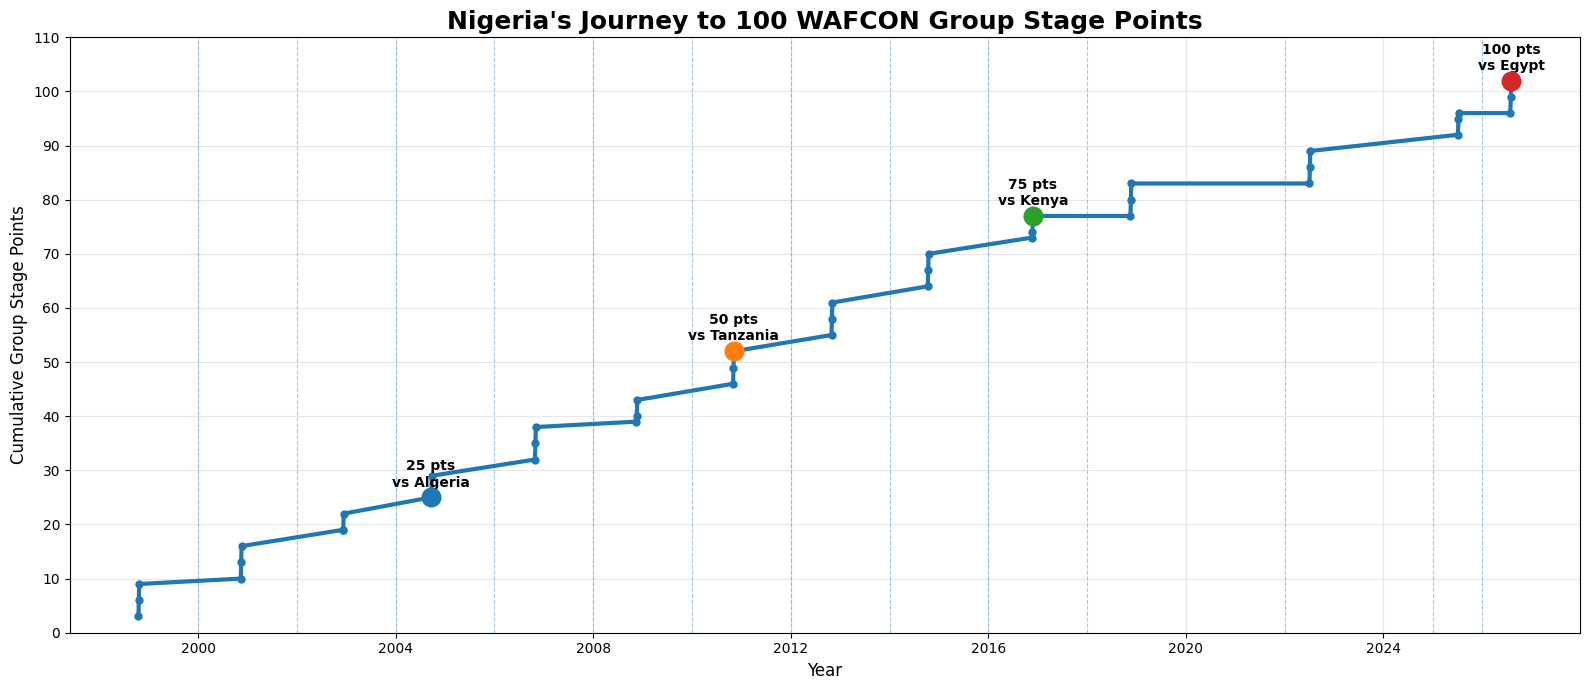

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Running Points Timeline
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,7))

# Main line
ax.plot(
    df["Date"],
    df["Running Points"],
    linewidth=3,
    marker="o",
    markersize=5
)

# -----------------------------------------------------------------------------
# Milestones
# -----------------------------------------------------------------------------

milestones = [25, 50, 75, 100]

for milestone in milestones:

    row = df[df["Running Points"] >= milestone].iloc[0]

    ax.scatter(
        row["Date"],
        row["Running Points"],
        s=180,
        zorder=5
    )

    ax.text(
        row["Date"],
        row["Running Points"] + 2,
        f'{milestone} pts\nvs {row["Opponent"]}',
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# -----------------------------------------------------------------------------
# Tournament Boundaries
# -----------------------------------------------------------------------------

years = sorted(df["Date"].dt.year.unique())

for year in years[1:]:
    ax.axvline(
        pd.Timestamp(f"{year}-01-01"),
        linestyle="--",
        linewidth=0.8,
        alpha=0.4
    )

# -----------------------------------------------------------------------------
# Styling
# -----------------------------------------------------------------------------

ax.set_title(
    "Nigeria's Journey to 100 WAFCON Group Stage Points",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative Group Stage Points", fontsize=12)

ax.set_ylim(0,110)

ax.set_yticks(range(0,111,10))

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

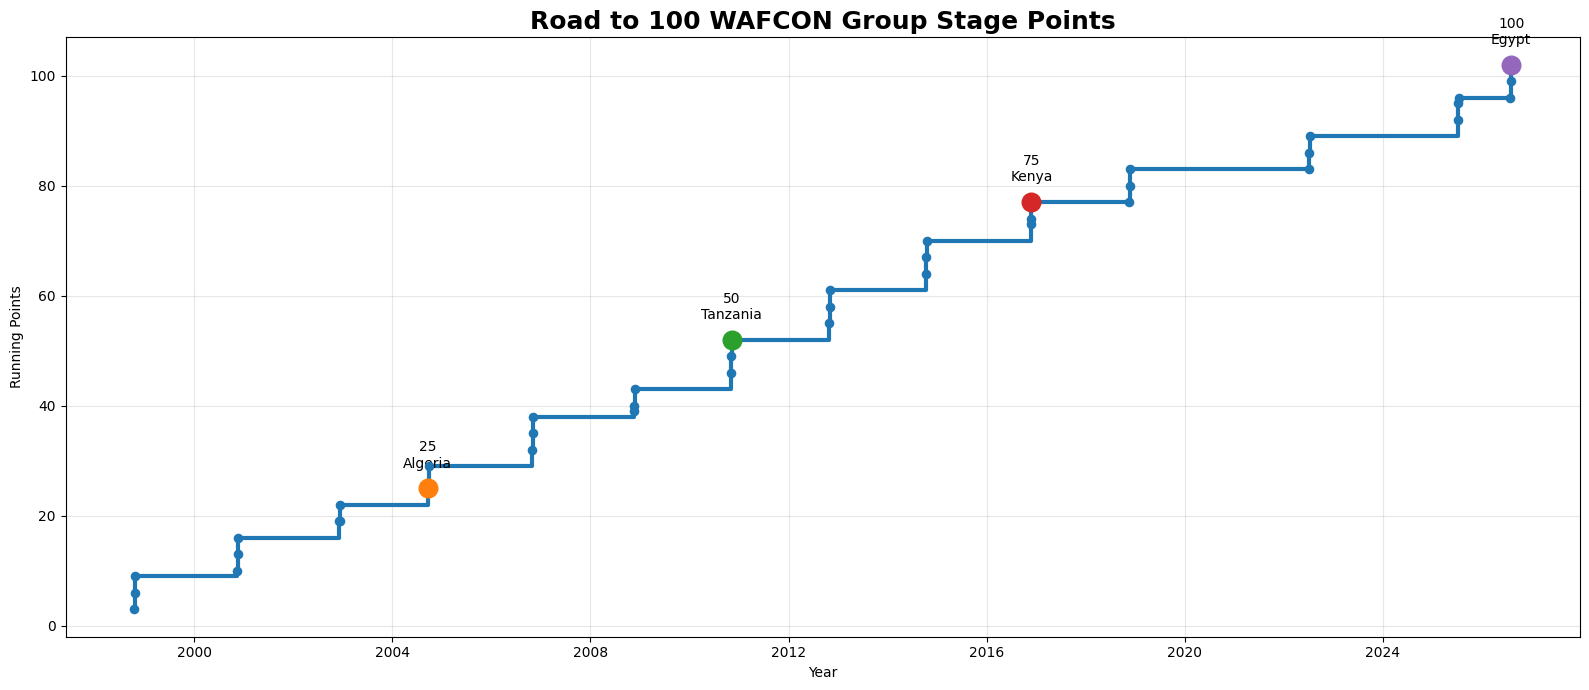

In [ ]:
fig, ax = plt.subplots(figsize=(16,7))

ax.step(
    df["Date"],
    df["Running Points"],
    where="post",
    linewidth=3
)

ax.scatter(
    df["Date"],
    df["Running Points"],
    s=35,
    zorder=5
)

# Milestones
for m in [25,50,75,100]:

    row = df[df["Running Points"] >= m].iloc[0]

    ax.scatter(
        row["Date"],
        row["Running Points"],
        s=180,
        zorder=6
    )

    ax.annotate(
        f"{m}\n{row['Opponent']}",
        (row["Date"], row["Running Points"]),
        xytext=(0,15),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Road to 100 WAFCON Group Stage Points",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Running Points")

ax.grid(alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
milestones = [1,25,50,75,100]

for point in milestones:
    row = df[df["Running Points"] >= point].iloc[0]
    print(f"\nPOINT {point}")
    print(row[[
        "Date",
        "Competition",
        "Opponent",
        "Result",
        "Running Points"
    ]])


POINT 1
Date                      1998-10-17 00:00:00
Competition       Womens Africa Cup of Nation
Opponent                              Morocco
Result                                      W
Running Points                              3
Name: 0, dtype: object

POINT 25
Date                      2004-09-19 00:00:00
Competition       Womens Africa Cup of Nation
Opponent                              Algeria
Result                                      W
Running Points                             25
Name: 9, dtype: object

POINT 50
Date                      2010-11-07 00:00:00
Competition       Womens Africa Cup of Nation
Opponent                             Tanzania
Result                                      W
Running Points                             52
Name: 20, dtype: object

POINT 75
Date                      2016-11-26 00:00:00
Competition       Womens Africa Cup of Nation
Opponent                                Kenya
Result                                      W
Running Points   

In [ ]:
# Performance by Tournament

summary = (
    df.groupby("Competition")
      .agg(
          Matches=("Result","count"),
          Wins=("Result",lambda x:(x=="W").sum()),
          Draws=("Result",lambda x:(x=="D").sum()),
          Losses=("Result",lambda x:(x=="L").sum()),
          Goals_For=("FTTG","sum"),
          Goals_Against=("FTOG","sum"),
          Clean_Sheets=("Clean_Sheet","sum"),
          Points=("Points","sum")
      )
)

summary["Goal Difference"] = summary["Goals_For"] - summary["Goals_Against"]

summary["Points Per Game"] = (
    summary["Points"] / summary["Matches"]
).round(2)

summary.reset_index()

,Competition,Matches,Wins,Draws,Losses,Goals_For,Goals_Against,Clean_Sheets,Points,Goal Difference,Points Per Game
0,Womens Africa Cup of Nation,42,32,6,4,133,23,27,102,110,2.43


In [ ]:
# Goals Through the Years

goals = (
    df.groupby("Competition")
      .agg(
          Matches=("Result","count"),
          Goals=("FTTG","sum")
      )
)

goals["Goals Per Match"] = (
    goals["Goals"] /
    goals["Matches"]
).round(2)

goals.reset_index()

,Competition,Matches,Goals,Goals Per Match
0,Womens Africa Cup of Nation,42,133,3.17


In [ ]:
# Highest scoring tournaments

print("Highest Scoring Tournaments")
print("=="*50)

team_goals = (
    df.groupby("Season")
      .agg(
          Matches=("Result","count"),
          Goals=("FTTG","sum")
      )
)

team_goals.sort_values("Goals", ascending=False)

Highest Scoring Tournaments


,Matches,Goals
Season,,
1998,3,20
2006,3,12
2014,3,12
2000,3,11
2016,3,11
2010,3,10
2018,3,10
2026,3,9
2004,3,9


In [ ]:
# Goals conceded by tournament

(
    df.groupby("Season")["FTOG"]
      .sum()
      .sort_values()
)

,FTOG
Season,
1998,0
2024,0
2010,1
2008,1
2016,1
2018,1
2004,2
2000,2
2012,2


In [ ]:
# Defensive Evolution

clean_sheet_pct = (
    df["Clean_Sheet"].sum() /
    len(df)
) * 100

print(f"Average Clean Sheet %: {clean_sheet_pct:.2f}%")

Average Clean Sheet %: 64.29%


In [ ]:
# Longest clean-sheet streak

streak = 0
best = 0

for cs in df["Clean_Sheet"]:
    if cs == 1:
        streak += 1
        best = max(best, streak)
    else:
        streak = 0

print(best)

5


In [ ]:
# Biggest Victories

# Winning margin


df["Goal Difference"] = df["FTTG"] - df["FTOG"]

largest = (
    df.sort_values(
        "Goal Difference",
        ascending=False
    )
)

largest[[
    "Date",
    "Competition",
    "Opponent",
    "FTTG",
    "FTOG",
    "Goal Difference"
]].head(10)

,Date,Competition,Opponent,FTTG,FTOG,Goal Difference
0,1998-10-17,Womens Africa Cup of Nation,Morocco,8,0,8
1,1998-10-20,Womens Africa Cup of Nation,Congo Kinshasa,6,0,6
2,1998-10-23,Womens Africa Cup of Nation,Egypt,6,0,6
4,2000-11-15,Womens Africa Cup of Nation,Morocco,6,0,6
25,2014-10-14,Womens Africa Cup of Nation,Zambia,6,0,6
13,2006-10-31,Womens Africa Cup of Nation,Algeria,6,0,6
27,2016-11-20,Womens Africa Cup of Nation,Mali,6,0,6
32,2018-11-24,Womens Africa Cup of Nation,Equatorial Guinea,6,0,6
18,2010-11-01,Womens Africa Cup of Nation,Mali,5,0,5
8,2002-12-13,Womens Africa Cup of Nation,Mali,5,1,4


In [ ]:
# Highest scoring wins

print("Highest Scoring Wins")
print("=="*50)

df.sort_values("FTTG", ascending=False)[[
    "Date",
    "Opponent",
    "FTTG",
    "FTOG"
]].head(10)

Highest Scoring Wins


,Date,Opponent,FTTG,FTOG
0,1998-10-17,Morocco,8,0
1,1998-10-20,Congo Kinshasa,6,0
2,1998-10-23,Egypt,6,0
4,2000-11-15,Morocco,6,0
25,2014-10-14,Zambia,6,0
41,2026-08-05,Egypt,6,2
27,2016-11-20,Mali,6,0
32,2018-11-24,Equatorial Guinea,6,0
13,2006-10-31,Algeria,6,0
8,2002-12-13,Mali,5,1


In [ ]:
# Toughest Opponents

print("Toughest Opponents")

opponents = (
    df.groupby("Opponent")
      .agg(
          Matches=("Result","count"),
          Wins=("Result",lambda x:(x=="W").sum()),
          Draws=("Result",lambda x:(x=="D").sum()),
          Losses=("Result",lambda x:(x=="L").sum()),
          Goals_For=("FTTG","sum"),
          Goals_Against=("FTOG","sum"),
          Points=("Points","sum")
      )
)

opponents["Win %"] = (
    opponents["Wins"] /
    opponents["Matches"] * 100
).round(1)

opponents.sort_values("Points")

Toughest Opponents


,Matches,Wins,Draws,Losses,Goals_For,Goals_Against,Points,Win %
Opponent,,,,,,,,
Malawi,1,0,0,1,2,3,0,0.0
Burundi,1,1,0,0,4,0,3,100.0
Ghana,4,0,3,1,4,5,3,0.0
Congo Kinshasa,1,1,0,0,6,0,3,100.0
Namibia,1,1,0,0,2,0,3,100.0
Kenya,1,1,0,0,4,0,3,100.0
Tanzania,1,1,0,0,3,0,3,100.0
Tunisia,2,1,1,0,3,0,4,50.0
Ivory Coast,2,2,0,0,7,3,6,100.0


In [ ]:
# Era Comparison

print("Era Comparison")
print("=="*50)

conditions = [
    df["Date"].dt.year <= 2006,
    (df["Date"].dt.year >= 2008) &
    (df["Date"].dt.year <= 2018),
    df["Date"].dt.year >= 2022
]

choices = [
    "1998-2006",
    "2008-2018",
    "2022-2026"
]

df["Era"] = np.select(
    conditions,
    choices,
    default="Other"
)

Era Comparison


In [ ]:
era = (
    df.groupby("Era")
      .agg(
          Matches=("Result","count"),
          Wins=("Result",lambda x:(x=="W").sum()),
          Draws=("Result",lambda x:(x=="D").sum()),
          Losses=("Result",lambda x:(x=="L").sum()),
          Goals=("FTTG","sum"),
          Conceded=("FTOG","sum"),
          Clean_Sheets=("Clean_Sheet","sum"),
          Points=("Points","sum")
      )
)

era["Win %"] = (
    era["Wins"] /
    era["Matches"] * 100
).round(1)

era

,Matches,Wins,Draws,Losses,Goals,Conceded,Clean_Sheets,Points,Win %
Era,,,,,,,,,
1998-2006,15,12,2,1,60,8,10,38,80.0
2008-2018,18,14,3,1,53,8,11,45,77.8
2022-2026,9,6,1,2,20,7,6,19,66.7


In [ ]:
# Era Comparison

print("Era v2 Comparison")
print("=="*50)

conditions = [
    df["Date"].dt.year <= 2008,
    (df["Date"].dt.year >= 2010) &
    (df["Date"].dt.year <= 2018),
    df["Date"].dt.year >= 2022
]

choices = [
    "1998-2008",
    "2010-2018",
    "2022-2026"
]

df["Era_2"] = np.select(
    conditions,
    choices,
    default="Other"
)

era_2 = (
    df.groupby("Era")
      .agg(
          Matches=("Result","count"),
          Wins=("Result",lambda x:(x=="W").sum()),
          Draws=("Result",lambda x:(x=="D").sum()),
          Losses=("Result",lambda x:(x=="L").sum()),
          Goals=("FTTG","sum"),
          Conceded=("FTOG","sum"),
          Clean_Sheets=("Clean_Sheet","sum"),
          Points=("Points","sum")
      )
)

era_2["Win %"] = (
    era_2["Wins"] /
    era_2["Matches"] * 100
).round(1)

era_2["Goal Difference"] = era_2["Goals"] - era_2["Conceded"]

era_2

Era v2 Comparison


,Matches,Wins,Draws,Losses,Goals,Conceded,Clean_Sheets,Points,Win %,Goal Difference
Era,,,,,,,,,,
1998-2006,15,12,2,1,60,8,10,38,80.0,52
2008-2018,18,14,3,1,53,8,11,45,77.8,45
2022-2026,9,6,1,2,20,7,6,19,66.7,13


In [ ]:
# First Half vs Full Time

print("First Half vs Full Time")
print("="*50)

led_ht = (df["HTTG"] > df["HTOG"]).sum()

draw_ht = (df["HTTG"] == df["HTOG"]).sum()

behind_ht = (df["HTTG"] < df["HTOG"]).sum()

print("Led at HT:", led_ht)
print("Level at HT:", draw_ht)
print("Behind at HT:", behind_ht)

First Half vs Full Time
Led at HT: 30
Level at HT: 10
Behind at HT: 2


In [ ]:
# Goals by half

print("Goals by half")
print("="*50)

first_half = df["HTTG"].sum()

second_half = (
    df["FTTG"] - df["HTTG"]
).sum()

print("H1", first_half)
print("H2", second_half)

Goals by half
H1 60
H2 73


In [ ]:
# Won after drawing at halftime

print("Won after drawing at halftime")
print("="*50)

df[
    (df["HTTG"] == df["HTOG"]) &
    (df["Result"]=="W")
]

Won after drawing at halftime


,Date,Season,Competition,Round,Group,Venue,Team,Opponent,HTTG,HTOG,FTTG,FTOG,FTR,Clean_Sheet,Team_Goals_Scorers,Opponent_Goals_Scorers,Result,Points,Running Points,Goal Difference,Era,Era_2
1,1998-10-20,1998,Womens Africa Cup of Nation,Group Stage,A,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Congo Kinshasa,0,0,6,0,6-0,True,NaN,NaN,W,3,6,6,1998-2006,1998-2008
2,1998-10-23,1998,Womens Africa Cup of Nation,Group Stage,A,Ahmadu Bello Stadium (Ranchers Bees),Nigeria,Egypt,0,0,6,0,6-0,True,NaN,NaN,W,3,9,6,1998-2006,1998-2008
24,2014-10-11,2014,Womens Africa Cup of Nation,Group Stage,A,"Sam Nujoma Stadium, Windhoek",Nigeria,Ivory Coast,1,1,4,2,4-2,False,Sunday (11)\nDiakité (54[og])\nDesire Oparanoz...,F. Coulibaly (21[pen])\nLohoues (75),W,3,64,2,2008-2018,2010-2018
37,2025-07-10,2024,Womens Africa Cup of Nation,Group Stage,B,"Stade Larbi Zaouli, Casablanca",Nigeria,Botswana,0,0,1,0,1-0,True,Chinwedu Ihezuo (89),NaN,W,3,95,1,2022-2026,2022-2026


In [ ]:
# # Goalscorer Analysis

# # Explode scorer column

# scorers = (
#     df["Goalscorers"]
#       .dropna()
#       .str.split(",")
#       .explode()
#       .str.strip()
# )

# goal_counts = scorers.value_counts()

# goal_counts


In [ ]:
# # Top scorers
# print("Top Scorers")
# print("="*50)
# goal_counts.head(20)

# # Unique scorers
# print("Unique Scorers")
# print("="*50)
# goal_counts.size

In [ ]:
# Winning Streaks

# Longest winning streak

print("Longest Winning Streak")
print("="*50)

current = 0
best = 0

for result in df["Result"]:
    if result == "W":
        current += 1
        best = max(best,current)
    else:
        current = 0

print(best)



Longest Winning Streak
11


In [ ]:
# Longest unbeaten streak

print("Longest Unbeaten Streak")
print("="*50)

current = 0
best = 0

for result in df["Result"]:
    if result != "L":
        current += 1
        best = max(best,current)
    else:
        current = 0

print(best)

Longest Unbeaten Streak
22


In [ ]:
# Perfect Group Stages

print("Perfect Group Stages")
print("="*50)

perfect = (
    summary[
        (summary["Wins"] == summary["Matches"])
    ]
)

perfect

Perfect Group Stages


,Matches,Wins,Draws,Losses,Goals_For,Goals_Against,Clean_Sheets,Points,Goal Difference,Points Per Game
Competition,,,,,,,,,,


In [ ]:
print("Perfect Group Stages (9 points earned in the Group Stage)")
print("=" * 50)

# The 'df' dataframe is loaded from 'nigeria_restructured_group_stages.csv',
# so it already contains only Nigeria's group stage matches.

# Group by Season to calculate points and matches per group stage
group_stage_performance = df.groupby('Season').agg(
    Total_Points=('Points', 'sum'),
    Matches_Played=('Result', 'count')
).reset_index()

# Filter for seasons where Nigeria achieved 9 points and played 3 matches
perfect_group_stages = group_stage_performance[
    (group_stage_performance['Total_Points'] == 9) &
    (group_stage_performance['Matches_Played'] == 3)
]

if not perfect_group_stages.empty:
    print("\nNigeria achieved a perfect group stage (9 points from 3 wins) in the following seasons:")
    for idx, row in perfect_group_stages.iterrows():
        print(f"  - Season {row['Season']}")
else:
    print("Nigeria did not achieve any perfect group stages (9 points from 3 wins).")

# Display the perfect group stages DataFrame (if any)
perfect_group_stages

Perfect Group Stages (9 points earned in the Group Stage)

Nigeria achieved a perfect group stage (9 points from 3 wins) in the following seasons:
  - Season 1998
  - Season 2006
  - Season 2010
  - Season 2012
  - Season 2014


,Season,Total_Points,Matches_Played
0,1998,9,3
4,2006,9,3
6,2010,9,3
7,2012,9,3
8,2014,9,3


In [ ]:
# Perfect defensive campaigns

print("Perfect Defense")
print("="*50)

summary[
    summary["Goals_Against"] == 0
]

Perfect Defense


,Matches,Wins,Draws,Losses,Goals_For,Goals_Against,Clean_Sheets,Points,Goal Difference,Points Per Game
Competition,,,,,,,,,,


In [ ]:
print("Perfect Defensive Campaigns (0 goals conceded in Group Stage)")
print("=" * 50)

# The 'df' dataframe is loaded from 'nigeria_restructured_group_stages.csv',
# so it already contains only Nigeria's group stage matches.

# Group by Season to calculate total goals conceded and matches played in the group stage
defensive_performance = df.groupby('Season').agg(
    Total_Goals_Conceded=('FTOG', 'sum'),
    Matches_Played=('Result', 'count') # Count the number of group stage matches
).reset_index()

# Filter for seasons where Nigeria conceded 0 goals and played 3 matches in the group stage
perfect_defensive_campaigns = defensive_performance[
    (defensive_performance['Total_Goals_Conceded'] == 0) &
    (defensive_performance['Matches_Played'] == 3)
]

if not perfect_defensive_campaigns.empty:
    print("\nNigeria had a perfect defensive group stage (0 goals conceded in 3 matches) in the following seasons:")
    for idx, row in perfect_defensive_campaigns.iterrows():
        print(f"  - Season {row['Season']}")
else:
    print("Nigeria did not have any perfect defensive group stages (0 goals conceded in 3 matches).")

# Display the perfect defensive campaigns DataFrame (if any)
perfect_defensive_campaigns

Perfect Defensive Campaigns (0 goals conceded in Group Stage)

Nigeria had a perfect defensive group stage (0 goals conceded in 3 matches) in the following seasons:
  - Season 1998
  - Season 2024


,Season,Total_Goals_Conceded,Matches_Played
0,1998,0,3
12,2024,0,3


In [ ]:
# Point Distribution

print("Point Distribution")
print("="*50)

available = len(df) * 3

earned = df["Points"].sum()

dropped = available - earned

print("Available:", available)
print("Earned:", earned)
print("Dropped:", dropped)

print(
    f"Percentage Won: {(earned/available)*100:.2f}%"
)

Point Distribution
Available: 126
Earned: 102
Dropped: 24
Percentage Won: 80.95%


In [ ]:
# Timeline of the Journey
timeline = df[[
    "Date",
    "Competition",
    "Opponent",
    "Result",
    "Running Points"
]]

timeline


,Date,Competition,Opponent,Result,Running Points
0,1998-10-17,Womens Africa Cup of Nation,Morocco,W,3
1,1998-10-20,Womens Africa Cup of Nation,Congo Kinshasa,W,6
2,1998-10-23,Womens Africa Cup of Nation,Egypt,W,9
3,2000-11-12,Womens Africa Cup of Nation,Ghana,D,10
4,2000-11-15,Womens Africa Cup of Nation,Morocco,W,13
5,2000-11-18,Womens Africa Cup of Nation,Cameroon,W,16
6,2002-12-06,Womens Africa Cup of Nation,Ethiopia,W,19
7,2002-12-10,Womens Africa Cup of Nation,Ghana,L,19
8,2002-12-13,Womens Africa Cup of Nation,Mali,W,22
9,2004-09-19,Womens Africa Cup of Nation,Algeria,W,25


In [ ]:

# Milestones

milestones = []

for p in [25,50,75,100]:
    row = df[df["Running Points"] >= p].iloc[0]
    milestones.append(row)

pd.DataFrame(milestones)[[
    "Date",
    "Competition",
    "Opponent",
    "Running Points"
]]

,Date,Competition,Opponent,Running Points
9,2004-09-19,Womens Africa Cup of Nation,Algeria,25
20,2010-11-07,Womens Africa Cup of Nation,Tanzania,52
29,2016-11-26,Womens Africa Cup of Nation,Kenya,77
41,2026-08-05,Womens Africa Cup of Nation,Egypt,102


In [ ]:
# Opponent Rankings

print("Most Faced Opponents")
print("="*50)
opponent_frequency = (
    df.groupby("Opponent")
      .size()
      .reset_index(name="Matches")
      .sort_values("Matches", ascending=False)
)

opponent_frequency


Most Faced Opponents


,Opponent,Matches
15,South Africa,5
8,Ghana,4
12,Mali,4
18,Zambia,3
3,Cameroon,3
0,Algeria,3
1,Botswana,2
17,Tunisia,2
9,Ivory Coast,2
6,Equatorial Guinea,2


In [ ]:

print("Biggest Victims (Highest Goals Per Match)")
print("="*50)

victims = (
    df.groupby("Opponent")
      .agg(
          Matches=("Result","count"),
          Goals_For=("FTTG","sum")
      )
)

victims["Goals Per Match"] = (
    victims["Goals_For"] /
    victims["Matches"]
).round(2)

victims.sort_values(
    "Goals Per Match",
    ascending=False
)

Biggest Victims (Highest Goals Per Match)


,Matches,Goals_For,Goals Per Match
Opponent,,,
Morocco,2,14,7.00
Congo Kinshasa,1,6,6.00
Egypt,2,12,6.00
Equatorial Guinea,2,10,5.00
Mali,4,19,4.75
Burundi,1,4,4.00
Kenya,1,4,4.00
Zambia,3,11,3.67
Ivory Coast,2,7,3.50


In [ ]:
print("Most Difficult Opponents (Points Per Match)")
print("="*50)

hardest = (
    df.groupby("Opponent")
      .agg(
          Matches=("Result","count"),
          Points=("Points","sum")
      )
)

hardest["PPG"] = (
    hardest["Points"] /
    hardest["Matches"]
).round(2)

hardest.sort_values("PPG")

Most Difficult Opponents (Points Per Match)


,Matches,Points,PPG
Opponent,,,
Malawi,1,0,0.00
Ghana,4,3,0.75
South Africa,5,9,1.80
Tunisia,2,4,2.00
Cameroon,3,7,2.33
Algeria,3,7,2.33
Botswana,2,6,3.00
Congo Kinshasa,1,3,3.00
Ethiopia,2,6,3.00


In [ ]:
# =============================================================================
# SECTION 16 - OPENING MATCH ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("SECTION 16 - OPENING MATCH ANALYSIS")
print("="*80)

opening_matches = (
    df.sort_values("Date")
      .groupby("Competition")
      .first()
      .reset_index()
)

print("\nOpening Match of Every Competition")
print(opening_matches[
    ["Competition","Date","Opponent","Result","FTTG","FTOG"]
])

print("\nOpening Match Results")
print(opening_matches["Result"].value_counts())

print(f"\nAverage Goals Scored in Opening Matches: {opening_matches['FTTG'].mean():.2f}")

print(f"Average Goals Conceded in Opening Matches: {opening_matches['FTOG'].mean():.2f}")

print(f"Opening Match Win Rate: {(opening_matches['Result']=='W').mean()*100:.1f}%")



# =============================================================================
# SECTION 17 - FINAL GROUP MATCH ANALYSIS
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 17 - FINAL GROUP MATCH ANALYSIS")
print("="*80)

closing_matches = (
    df.sort_values("Date")
      .groupby("Competition")
      .last()
      .reset_index()
)

print("\nFinal Match of Every Competition")
print(closing_matches[
    ["Competition","Date","Opponent","Result","FTTG","FTOG"]
])

print("\nFinal Match Results")
print(closing_matches["Result"].value_counts())

print(f"\nAverage Goals Scored in Final Matches: {closing_matches['FTTG'].mean():.2f}")

print(f"Average Goals Conceded in Final Matches: {closing_matches['FTOG'].mean():.2f}")

print(f"Final Match Win Rate: {(closing_matches['Result']=='W').mean()*100:.1f}%")



# =============================================================================
# SECTION 18 - SCORING TRENDS
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 18 - SCORING TRENDS")
print("="*80)

for level in [1,2,3,4,5]:
    pct = (df["FTTG"] >= level).mean()*100
    count = (df["FTTG"] >= level).sum()

    print(f"Matches with {level}+ goals: {count} ({pct:.1f}%)")

print("\nGoal Frequency")

goal_frequency = (
    df["FTTG"]
    .value_counts()
    .sort_index()
)

print(goal_frequency)



# =============================================================================
# SECTION 19 - COMEBACKS & GAME MANAGEMENT
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 19 - COMEBACKS & GAME MANAGEMENT")
print("="*80)

print("\nWins After Trailing At Half-Time")

won_from_behind = df[
    (df["HTTG"] < df["HTOG"]) &
    (df["Result"]=="W")
]

print(won_from_behind[
    ["Date","Competition","Opponent","HTTG","HTOG","FTTG","FTOG"]
])

print(f"Total: {len(won_from_behind)}")


print("\nWins After Drawing At Half-Time")

won_after_draw = df[
    (df["HTTG"] == df["HTOG"]) &
    (df["Result"]=="W")
]

print(won_after_draw[
    ["Date","Competition","Opponent","HTTG","HTOG","FTTG","FTOG"]
])

print(f"Total: {len(won_after_draw)}")


print("\nFailed To Win After Leading At Half-Time")

failed_after_lead = df[
    (df["HTTG"] > df["HTOG"]) &
    (df["Result"]!="W")
]

print(failed_after_lead[
    ["Date","Competition","Opponent","Result","FTTG","FTOG"]
])

print(f"Total: {len(failed_after_lead)}")


print("\nMatches Led At Half-Time And Won")

led_all_the_way = df[
    (df["HTTG"] > df["HTOG"]) &
    (df["Result"]=="W")
]

print(f"Total: {len(led_all_the_way)}")



# =============================================================================
# SECTION 20 - GOAL SCORING CONSISTENCY
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 20 - GOAL SCORING CONSISTENCY")
print("="*80)


def longest_streak(series, minimum):

    current = 0
    best = 0

    for value in series:

        if value >= minimum:
            current += 1
            best = max(best,current)

        else:
            current = 0

    return best


print(f"Longest Scoring Streak (1+ Goals): {longest_streak(df['FTTG'],1)} matches")

print(f"Longest 2+ Goal Streak: {longest_streak(df['FTTG'],2)} matches")

print(f"Longest 3+ Goal Streak: {longest_streak(df['FTTG'],3)} matches")

print(f"Longest 4+ Goal Streak: {longest_streak(df['FTTG'],4)} matches")



# =============================================================================
# SECTION 21 - SHUTOUT ANALYSIS
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 21 - SHUTOUT ANALYSIS")
print("="*80)

clean_sheet_pct = df["Clean_Sheet"].mean()*100

print(f"Clean_Sheets: {df['Clean_Sheet'].sum()}")

print(f"Clean_Sheet Percentage: {clean_sheet_pct:.1f}%")

print("\nMatches Nigeria Failed To Score")

failed_to_score = df[df["FTTG"]==0]

print(failed_to_score[
    ["Date","Competition","Opponent","Result"]
])

print(f"Total: {len(failed_to_score)}")



# =============================================================================
# SECTION 22 - MARGIN OF VICTORY DISTRIBUTION
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 22 - MARGIN OF VICTORY DISTRIBUTION")
print("="*80)

df["Margin"] = df["FTTG"] - df["FTOG"]

margin_distribution = (
    df[df["Result"]=="W"]
      .groupby("Margin")
      .size()
      .rename("Wins")
)

print(margin_distribution)



# =============================================================================
# SECTION 23 - FIRST HALF VS SECOND HALF GOALS
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 23 - FIRST HALF VS SECOND HALF GOALS")
print("="*80)

first_half = df["HTTG"].sum()

second_half = (
    df["FTTG"] -
    df["HTTG"]
).sum()

total_goals = first_half + second_half

print(f"First Half Goals : {first_half}")

print(f"Second Half Goals: {second_half}")

print(f"Total Goals      : {total_goals}")

print(f"\nFirst Half Percentage : {first_half/total_goals:.1%}")

print(f"Second Half Percentage: {second_half/total_goals:.1%}")



# =============================================================================
# SECTION 24 - Competition SUPERLATIVES
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 24 - Competition SUPERLATIVES")
print("="*80)

print("\nHighest Scoring Competition")
print(summary.sort_values("Goals_For",ascending=False).head(1))

print("\nBest Defensive Competition")
print(summary.sort_values("Goals_Against").head(1))

print("\nBest Goal Difference")
print(summary.sort_values("Goal Difference",ascending=False).head(1))

print("\nMost Points Won")
print(summary.sort_values("Points",ascending=False).head(1))

print("\nHighest Points Per Game")
print(summary.sort_values("Points Per Game",ascending=False).head(3))



# =============================================================================
# SECTION 25 - OPPONENT RANKINGS
# =============================================================================

print("\n\n" + "="*80)
print("SECTION 25 - OPPONENT RANKINGS")
print("="*80)

print("\nMost Faced Opponents")

opponent_frequency = (
    df.groupby("Opponent")
      .size()
      .reset_index(name="Matches")
      .sort_values("Matches",ascending=False)
)

print(opponent_frequency)


print("\nBiggest Victims (Goals Per Match)")

victims = (
    df.groupby("Opponent")
      .agg(
          Matches=("Result","count"),
          Goals_For=("FTTG","sum")
      )
)

victims["Goals Per Match"] = (
    victims["Goals_For"] /
    victims["Matches"]
).round(2)

print(victims.sort_values("Goals Per Match",ascending=False))


print("\nToughest Opponents (Points Per Match)")

hardest = (
    df.groupby("Opponent")
      .agg(
          Matches=("Result","count"),
          Points=("Points","sum")
      )
)

hardest["Points Per Match"] = (
    hardest["Points"] /
    hardest["Matches"]
).round(2)

print(hardest.sort_values("Points Per Match"))


SECTION 16 - OPENING MATCH ANALYSIS

Opening Match of Every Competition
                   Competition       Date Opponent Result  FTTG  FTOG
0  Womens Africa Cup of Nation 1998-10-17  Morocco      W     8     0

Opening Match Results
Result
W    1
Name: count, dtype: int64

Average Goals Scored in Opening Matches: 8.00
Average Goals Conceded in Opening Matches: 0.00
Opening Match Win Rate: 100.0%


SECTION 17 - FINAL GROUP MATCH ANALYSIS

Final Match of Every Competition
                   Competition       Date Opponent Result  FTTG  FTOG
0  Womens Africa Cup of Nation 2026-08-05    Egypt      W     6     2

Final Match Results
Result
W    1
Name: count, dtype: int64

Average Goals Scored in Final Matches: 6.00
Average Goals Conceded in Final Matches: 2.00
Final Match Win Rate: 100.0%


SECTION 18 - SCORING TRENDS
Matches with 1+ goals: 38 (90.5%)
Matches with 2+ goals: 32 (76.2%)
Matches with 3+ goals: 24 (57.1%)
Matches with 4+ goals: 17 (40.5%)
Matches with 5+ goals: 11 (26.2%)



In [ ]:
%%capture
!pip install nbconvert

In [ ]:
%%capture
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

In [ ]:
# %%capture
!jupyter nbconvert --to pdf wafcon.ipynb

[NbConvertApp] WARNING | pattern 'wafcon.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Exec

In [ ]:
# %%capture
# !wget -nc https://raw.githubusercontent.com/brpy/colab-pdf/master/colab_pdf.py
# from colab_pdf import colab_pdf
# colab_pdf('wafcon.ipynb')

# Task
To save the `nga_fixed_gls` DataFrame to a new, uniquely named sheet in the Google Spreadsheet, I'll first convert it to a list of lists. Then, I'll create a new worksheet in the spreadsheet identified by `'1jusUj_wGLSsAtTevm3sZ-wgjgjkQzWvf1ROL8tDNQdg'` with a timestamped name to ensure uniqueness. Finally, I will upload the DataFrame's headers and data to this new worksheet and print the URL for easy access.

This process will create a new snapshot of the `nga_fixed_gls` DataFrame each time it's executed, without overwriting previous data.

## Save nga_fixed_gls to Google Sheet

### Subtask:
Convert the `nga_fixed_gls` DataFrame to a list of lists and create a new worksheet in the Google Sheet with a unique, timestamped name. Then, upload the DataFrame's headers and data to this new worksheet, ensuring that no existing data is overwritten and a new snapshot is created with each execution. Print the URL of the newly created sheet for easy access.


**Reasoning**:
The subtask requires saving the `nga_fixed_gls` DataFrame to a Google Sheet. I will start by importing the `datetime` module, converting the DataFrame to a list of lists including headers, generating a unique timestamped sheet name, opening the Google Spreadsheet, adding a new worksheet, updating it with the data, and finally printing the URL for access.



In [ ]:
import datetime

# 2. Convert the nga_fixed_gls DataFrame, including headers, into a list of lists.
data_to_upload = [nga_fixed_gls.columns.values.tolist()] + nga_fixed_gls.values.tolist()

# 3. Generate a unique sheet name using the current timestamp.
sheet_name = f'nga_fixed_gls_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}'

# 4. Open the Google Spreadsheet with the ID '1jusUj_wGLSsAtTevm3sZ-wgjgjkQzWvf1ROL8tDNQdg' using gc.open_by_key().
spreadsheet_id = '1jusUj_wGLSsAtTevm3sZ-wgjgjkQzWvf1ROL8tDNQdg'
spreadsheet = gc.open_by_key(spreadsheet_id)

# 5. Add a new worksheet to the spreadsheet with the generated sheet_name.
worksheet = spreadsheet.add_worksheet(title=sheet_name, rows=len(data_to_upload), cols=len(nga_fixed_gls.columns))

# 6. Update the newly created worksheet with the data_to_upload.
worksheet.update(data_to_upload)

# 7. Print a success message including the URL of the new worksheet.
print(f"Successfully uploaded `nga_fixed_gls` to Google Sheet: {worksheet.url}")

Successfully uploaded `nga_fixed_gls` to Google Sheet: https://docs.google.com/spreadsheets/d/1jusUj_wGLSsAtTevm3sZ-wgjgjkQzWvf1ROL8tDNQdg#gid=132559906
